# Analysis

In [1]:
import os, sys

# Environment setup (equivalent to shell exports)
sys.path.insert(0, os.path.abspath(".."))
os.environ["SSL_CERT_DIR"] = "/etc/ssl/certs"
os.environ.setdefault("OPENCLIP_CACHEDIR", os.path.expandvars("$SCRATCH/openclip"))

'/network/scratch/m/marawan.gamal/openclip'

In [4]:
import torch

def _get_eigcov(d: torch.Tensor, *args, **kwargs):
    c = d.transpose(1, 2) @ d
    return c

pinv = torch.linalg.pinv

d = torch.randn(3, 32, 64)
# c = d.transpose(1, 2) @ d
c = _get_eigcov(d)
gam = 1 / torch.linalg.norm(d, ord="fro", dim=(-2, -1), keepdim=True)
(gam * d @ c).sum(dim=0) @ pinv((c * gam).sum(dim=0))

tensor([[-2.6291,  0.6043, -1.4570,  ..., -1.9519, -1.0970, -2.6682],
        [-3.1135,  1.4433, -3.3082,  ..., -0.4828, -0.9028, -0.1780],
        [ 1.6258, -0.6673,  0.8650,  ..., -0.2050,  1.7706, -2.2243],
        ...,
        [-2.7072, -2.4659,  3.6469,  ..., -1.6393,  0.5539,  4.3920],
        [ 1.1074,  1.8754, -2.4101,  ..., -2.2259,  0.1869, -0.4476],
        [ 3.3741, -1.1734,  4.3388,  ...,  2.5122, -2.9719, -1.4882]])

## Fig. 1a: EigCov Estimation Error (Vision)

In [ ]:
import sys
import os
import math
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import LinearizedTaskVector, NonLinearTaskVector


MODELS = ["ViT-B-16", "ViT-L-14"]
# MODELS = ["ViT-B-16"]
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
FT_METHODS = ["standard"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
def dist_cos_noabs(A: torch.Tensor, B: torch.Tensor, *args, **kwargs) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    cos_theta = torch.dot(a, b) / (a.norm() * b.norm())
    return (1 - cos_theta)

max_layers_per_combo = MAX_LAYERS + 1 if MAX_LAYERS is not None else None
TOTAL = len(MODELS) * len(FT_METHODS) * len(DATASETS) * (max_layers_per_combo or 0)
global_step = 0

rows = []
for model_name in MODELS:
    results_dir = os.path.join(RESULTS_ROOT, model_name)
    checkpoint_dir = os.path.join(CHECKPOINTS_ROOT, model_name)
    # checkpoint_dir = f"../checkpoints/{model_name}"

    for ft_method, dataset in product(FT_METHODS, DATASETS):
        # Load covariance
        covs = np.load(f"{results_dir}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{ft_method}/covariance_{dataset}.npz", allow_pickle=True)

        # Load task vector
        if ft_method == "linear":
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/linear_zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/linear_finetuned.pt"
            pretrained_nonlinear_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"

            nonlinear_encoder = torch.load(
                pretrained_nonlinear_checkpoint, map_location="cpu", weights_only=False
            )
            param_names = [n for n, _ in nonlinear_encoder.named_parameters()]
            del nonlinear_encoder

            tv = LinearizedTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )
            encoder = tv.apply_to_nonlinear(
                pretrained_nonlinear_checkpoint, param_names, scaling_coef=1.0
            )
            task_vector = NonLinearTaskVector(
                vector=encoder.state_dict(),
            )
        elif ft_method == "lora":
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/lora_finetuned.pt"
            task_vector = NonLinearTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )
        else:
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/finetuned.pt"
            task_vector = NonLinearTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )

        task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

        num_added = 0
        if TOTAL == 0 and MAX_LAYERS is None:
            TOTAL = len(MODELS) * len(FT_METHODS) * len(DATASETS) * len(task_vector.vector)
        for k, d in task_vector.vector.items():
            kp = param_name_to_module_name(k)
            if len(d.shape) != 2 or kp not in covs.keys():
                continue
            d = d.to(DEVICE)
            c = torch.from_numpy(covs[kp]).to(d.dtype).to(DEVICE)
            c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=DEVICE)
            c_hat_ec = d.T @ d
            c_hat_rand = torch.randn_like(c, device=DEVICE)
            for method, c_hat in [
                ("EigenCov", c_hat_ec),
                ("Random", c_hat_rand),
                ("Identity", c_hat_ident),
            ]:
                rows.append({
                    "model": model_name, "dataset": dataset, "layer_name": k,
                    "layer_idx": num_added, "method": method,
                    "error": dist_cos_noabs(c, c_hat).item(), "ft_method": ft_method,
                })
            global_step += 1
            print(f"[{global_step}/{TOTAL}] {model_name} | {ft_method} | {dataset} | layer {num_added} | {k.split('.')[-2]}")
            num_added += 1
            if MAX_LAYERS is not None and num_added > MAX_LAYERS:
                break

# Save
df = pd.DataFrame(rows)
df.to_csv(SAVE_PATH, index=False)

[1/2472] ViT-B-16 | standard | Cars | layer 0 | c_fc
[2/2472] ViT-B-16 | standard | Cars | layer 1 | c_proj
[3/2472] ViT-B-16 | standard | Cars | layer 2 | c_fc
[4/2472] ViT-B-16 | standard | Cars | layer 3 | c_proj
[5/2472] ViT-B-16 | standard | Cars | layer 4 | c_fc
[6/2472] ViT-B-16 | standard | Cars | layer 5 | c_proj
[7/2472] ViT-B-16 | standard | Cars | layer 6 | c_fc
[8/2472] ViT-B-16 | standard | Cars | layer 7 | c_proj
[9/2472] ViT-B-16 | standard | Cars | layer 8 | c_fc
[10/2472] ViT-B-16 | standard | Cars | layer 9 | c_proj
[11/2472] ViT-B-16 | standard | Cars | layer 10 | c_fc
[12/2472] ViT-B-16 | standard | Cars | layer 11 | c_proj
[13/2472] ViT-B-16 | standard | Cars | layer 12 | c_fc
[14/2472] ViT-B-16 | standard | Cars | layer 13 | c_proj
[15/2472] ViT-B-16 | standard | Cars | layer 14 | c_fc
[16/2472] ViT-B-16 | standard | Cars | layer 15 | c_proj
[17/2472] ViT-B-16 | standard | Cars | layer 16 | c_fc
[18/2472] ViT-B-16 | standard | Cars | layer 17 | c_proj
[19/2472] V

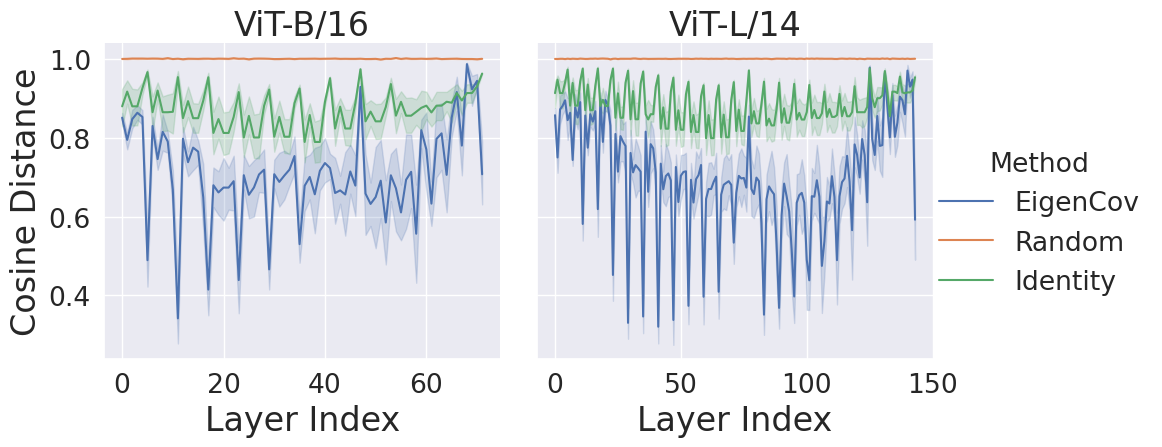

In [38]:
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}

df = pd.read_csv(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = df[df["ft_method"] == "standard"]
df = df[df["method"] != "Zeros"]
df["model"] = df["model"].map(MODEL_MAP).fillna(df["model"])

# Re-index layers: natural sort by layer_name within each model
def natural_sort_key(s):
    return [int(tok) if tok.isdigit() else tok for tok in re.split(r'(\d+)', s)]

for model in df["model"].unique():
    sorted_layers = sorted(df.loc[df["model"] == model, "layer_name"].unique(), key=natural_sort_key)
    layer_to_idx = {name: idx for idx, name in enumerate(sorted_layers)}
    df.loc[df["model"] == model, "layer_idx"] = df.loc[df["model"] == model, "layer_name"].map(layer_to_idx)
df["layer_idx"] = df["layer_idx"].astype(int)
df = df.sort_values("layer_idx")

g = sns.relplot(
    data=df,
    x="layer_idx",
    y="error",
    hue="method",
    col="model",
    kind="line",
    legend="brief",
    facet_kws={"sharey": True, "sharex": False},
)

g.set_axis_labels("Layer Index", "Cosine Distance")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Method")
g.figure.savefig(
    f"../results/eigcov_estimation_error_vision_layer_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

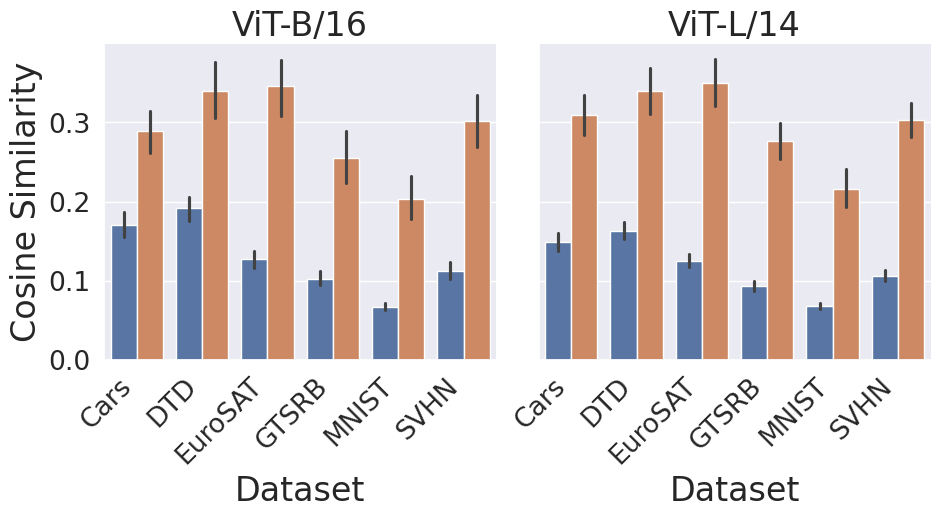

In [33]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}

df = pd.read_csv(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = df[df["ft_method"] == "standard"]
df = df[df["method"] != "Zeros"]
df = df[df["method"] != "Random"]
df["model"] = df["model"].map(MODEL_MAP).fillna(df["model"])
df["cos_sim"] = (1 - df["error"])

g = sns.catplot(
    data=df,
    x="dataset",
    y="cos_sim",
    hue="method",
    col="model",
    kind="bar",
    legend=False,
    sharey=True,
    hue_order=["Identity", "EigenCov"],
    # palette = {"EigenCov": sns.color_palette()[0], "Identity": sns.color_palette()[1], "Random": sns.color_palette()[2]}
)

g.set_axis_labels("Dataset", "Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=45, ha="right")
g.figure.savefig(
    f"../results/eigcov_estimation_error_vision_dataset_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

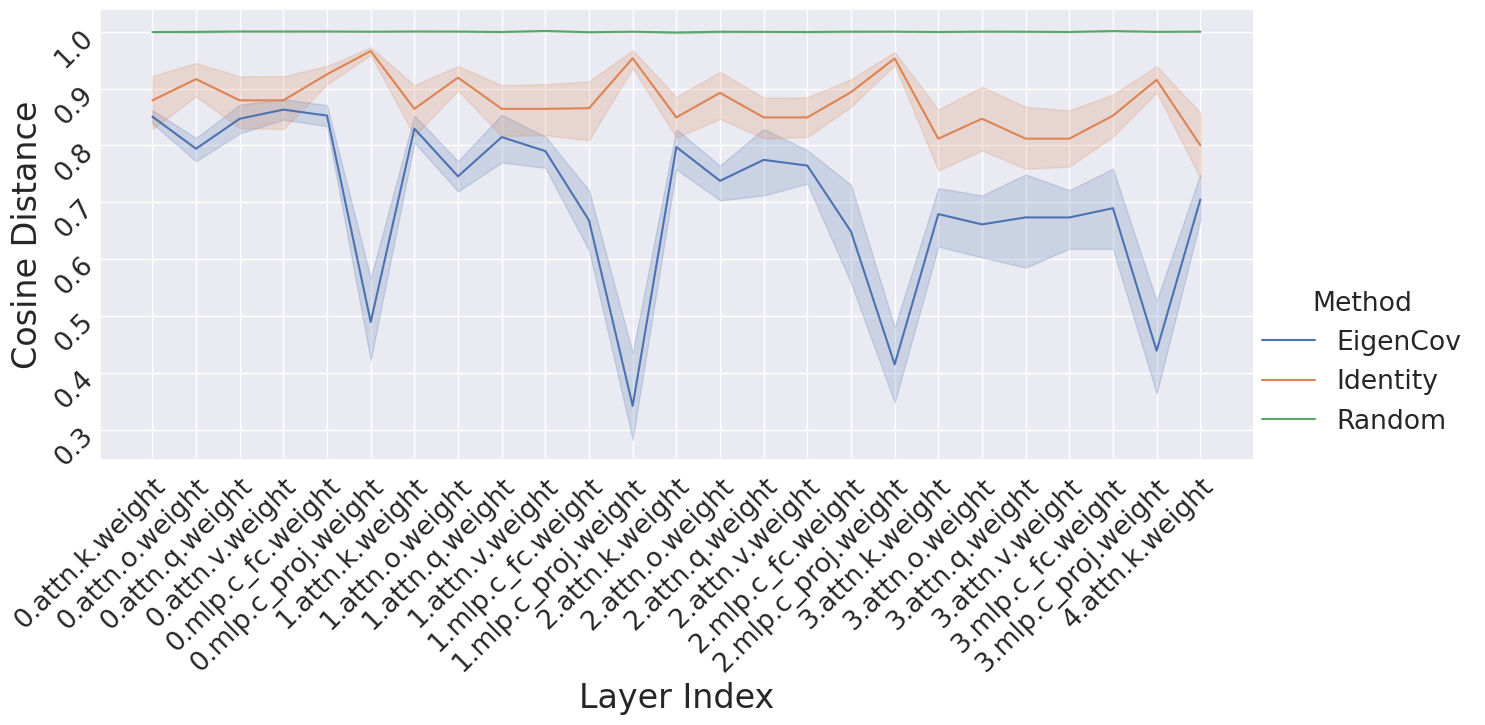

In [40]:
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

df = pd.read_csv(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = df[df["ft_method"] == "standard"]
df = df[df["method"] != "Zeros"]
df = df[df["model"] == "ViT-B-16"]

# Re-index layers: natural sort by layer_name
def natural_sort_key(s):
    return [int(tok) if tok.isdigit() else tok for tok in re.split(r'(\d+)', s)]

sorted_layers = sorted(df["layer_name"].unique(), key=natural_sort_key)
layer_to_idx = {name: idx for idx, name in enumerate(sorted_layers)}
df["layer_idx"] = df["layer_name"].map(layer_to_idx).astype(int)

df = df[df["layer_idx"] < 25]
df['layer_abbrv'] = df['layer_name'].apply(lambda k: k.replace("model.visual.transformer.resblocks.", ""))
df = df.sort_values("layer_idx")

g = sns.relplot(
    data=df,
    x="layer_abbrv",
    y="error",
    hue="method",
    kind="line",
    legend="brief",
    facet_kws={"sharey": True},
    height=6,
    aspect=2.2,
    hue_order=["EigenCov", "Identity", "Random"],
)

g.set_axis_labels("Layer Index", "Cosine Distance")
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=45, ha='right', rotation_mode='anchor')

if g.legend:
    g.legend.set_title("Method")

## Fig. 1b: EigCov Estimation Error (Language)

In [ ]:
import sys
import os
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd

sys.path.append("..")
from src.language.task_vectors import LanguageNonLinearTaskVector

MODELS = ["t5-base", "t5-large"]
DATASETS = ["qasc", "wiki_qa", "quartz", "paws", "story_cloze", "winogrande", "wsc"]
FT_METHODS = ["standard"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
LOW_SAMPLE_COUNTS = [1, 10, 100, 500, 1000]
LOW_SAMPLE_BATCH_SIZE = 1
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

param_key_to_cov_key = lambda name: name.replace(".weight", "")

def dist_cos_noabs(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    cos_theta = torch.dot(a, b) / (a.norm() * b.norm())
    return (1 - cos_theta)

rows = []
for model_name in MODELS:
    results_dir = os.path.join(RESULTS_ROOT, model_name)
    checkpoint_dir = os.path.join(CHECKPOINTS_ROOT, model_name)

    for ft_method, dataset in product(FT_METHODS, DATASETS):
        cov_path = f"{results_dir}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_efull_ft{ft_method}/covariance_{dataset}.npz"
        if not os.path.exists(cov_path):
            print(f"Missing covariance: {cov_path}")
            continue
        covs = np.load(cov_path, allow_pickle=True)

        # Load low-sample covariances
        low_sample_covs = {}
        for ns in LOW_SAMPLE_COUNTS:
            ls_path = f"{results_dir}/covariances_strain_n{ns}_b{LOW_SAMPLE_BATCH_SIZE}_tsm_efull_ft{ft_method}/covariance_{dataset}.npz"
            if os.path.exists(ls_path):
                low_sample_covs[ns] = np.load(ls_path, allow_pickle=True)
            else:
                print(f"Missing low-sample covariance (n={ns}): {ls_path}")

        pretrained_checkpoint = f"{checkpoint_dir}/{dataset}/zeroshot.pt"
        finetuned_checkpoint = f"{checkpoint_dir}/{dataset}/finetuned.pt"
        task_vector = LanguageNonLinearTaskVector(
            pretrained_checkpoint,
            finetuned_checkpoint,
        )

        num_added = 0
        for k, d in task_vector.vector.items():
            kp = param_key_to_cov_key(k)
            if len(d.shape) != 2 or kp not in covs.keys():
                continue
            d = d.to(DEVICE)
            c = torch.from_numpy(covs[kp]).to(d.dtype).to(DEVICE)
            c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=DEVICE)
            c_hat_ec = d.T @ d
            c_hat_rand = torch.randn_like(c, device=DEVICE)

            methods = [
                ("EigenCov", c_hat_ec),
                ("Random", c_hat_rand),
                ("Identity", c_hat_ident),
            ]
            for ns, ls_covs in low_sample_covs.items():
                if kp in ls_covs.keys():
                    c_hat_ls = torch.from_numpy(ls_covs[kp]).to(d.dtype).to(DEVICE)
                    methods.append((f"Cov (n={ns})", c_hat_ls))

            for method, c_hat in methods:
                rows.append({
                    "model": model_name, "dataset": dataset, "layer_name": k,
                    "layer_idx": num_added, "method": method,
                    "error": dist_cos_noabs(c, c_hat).item(), "ft_method": ft_method,
                })
            num_added += 1
            print(f"{model_name} | {ft_method} | {dataset} | layer {num_added} | {k.split('.')[-2]}")

df_lang = pd.DataFrame(rows)
df_lang.to_csv(SAVE_PATH, index=False)

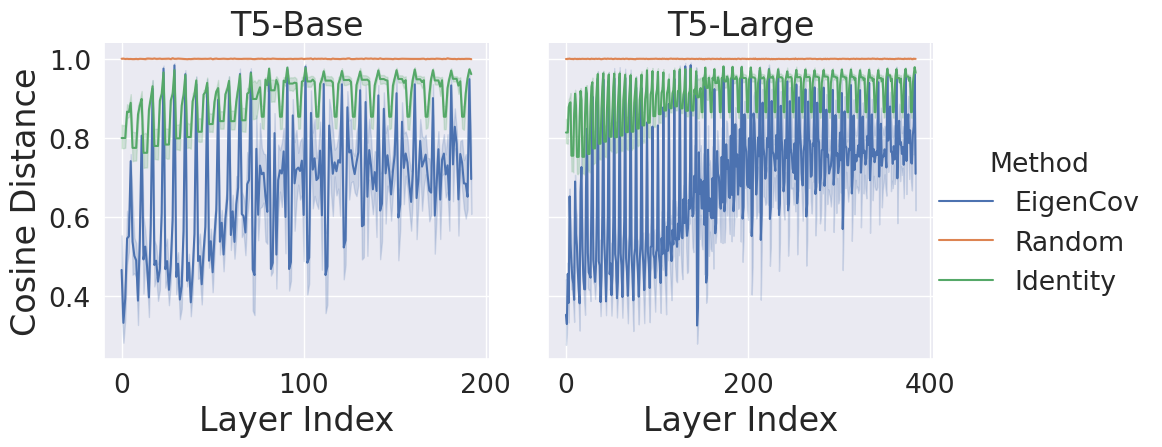

In [58]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

df_lang = pd.read_csv(f"../results/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df_lang = df_lang[df_lang["ft_method"] == "standard"]
df_lang = df_lang[df_lang["method"] != "Zeros"]
df_lang["model"] = df_lang["model"].map(MODEL_MAP).fillna(df_lang["model"])

g = sns.relplot(
    data=df_lang,
    x="layer_idx",
    y="error",
    hue="method",
    col="model",
    kind="line",
    legend="brief",
    facet_kws={"sharey": True, "sharex": False},
)

g.set_axis_labels("Layer Index", "Cosine Distance")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Method")
g.figure.savefig(
    f"../results/eigcov_estimation_error_lang_layer_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

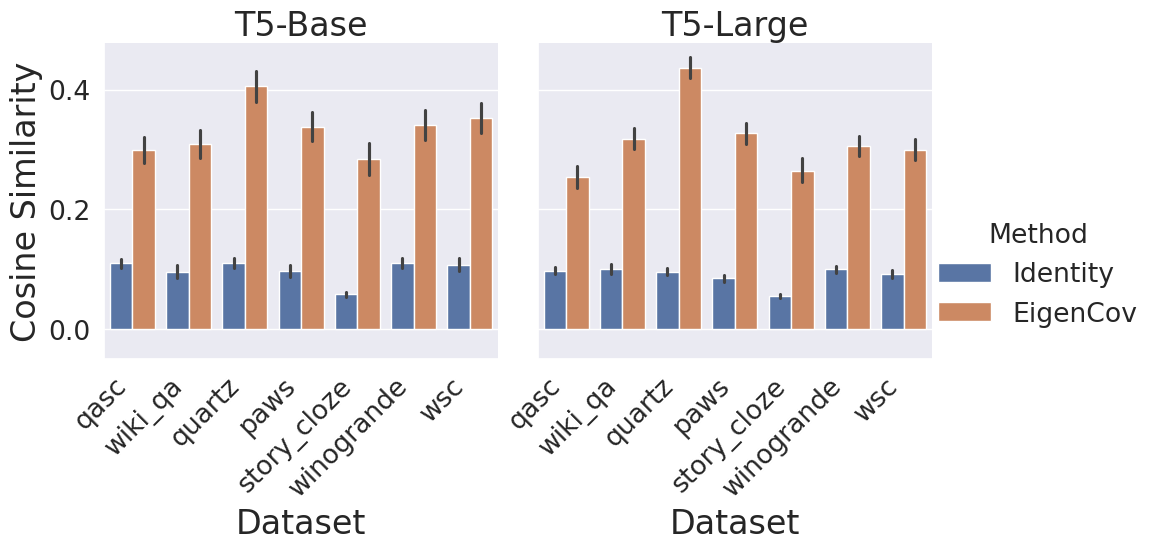

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10


sns.set_theme(
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

df_lang = pd.read_csv(f"../results/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df_lang = df_lang[df_lang["ft_method"] == "standard"]
df_lang = df_lang[df_lang["method"] != "Zeros"]
df_lang = df_lang[df_lang["method"] != "Random"]
df_lang["model"] = df_lang["model"].map(MODEL_MAP).fillna(df_lang["model"])
df_lang["cos_sim"] = (1 - df_lang["error"])

g = sns.catplot(
    data=df_lang,
    x="dataset",
    y="cos_sim",
    hue="method",
    col="model",
    kind="bar",
    legend="brief",
    sharey=True,
    hue_order=["Identity", "EigenCov"],
)

g.set_axis_labels("Dataset", "Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Method")
g.set_xticklabels(rotation=45, ha="right")
g.figure.savefig(
    f"../results/eigcov_estimation_error_lang_dataset_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

## Fig. 1c: EigCov Estimation Error (Combined)

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BATCH_SIZE, NUM_SAMPLES = 32, 10
VISION_MODELS = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}
LANG_MODELS = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

def load_and_prep(path, model_map):
    df = pd.read_csv(path)
    df = df[(df["ft_method"] == "standard") & ~df["method"].isin(["Zeros", "Random"])]
    df["model"] = df["model"].map(model_map).fillna(df["model"])
    df["cos_sim"] = 1 - df["error"]
    return df

df = pd.concat([
    load_and_prep(f"../results-v2/misc/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", VISION_MODELS),
    load_and_prep(f"../results-v2/misc/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", LANG_MODELS),
], ignore_index=True)

df = df[df["model"].isin(["ViT-L/14", "T5-Large"])]

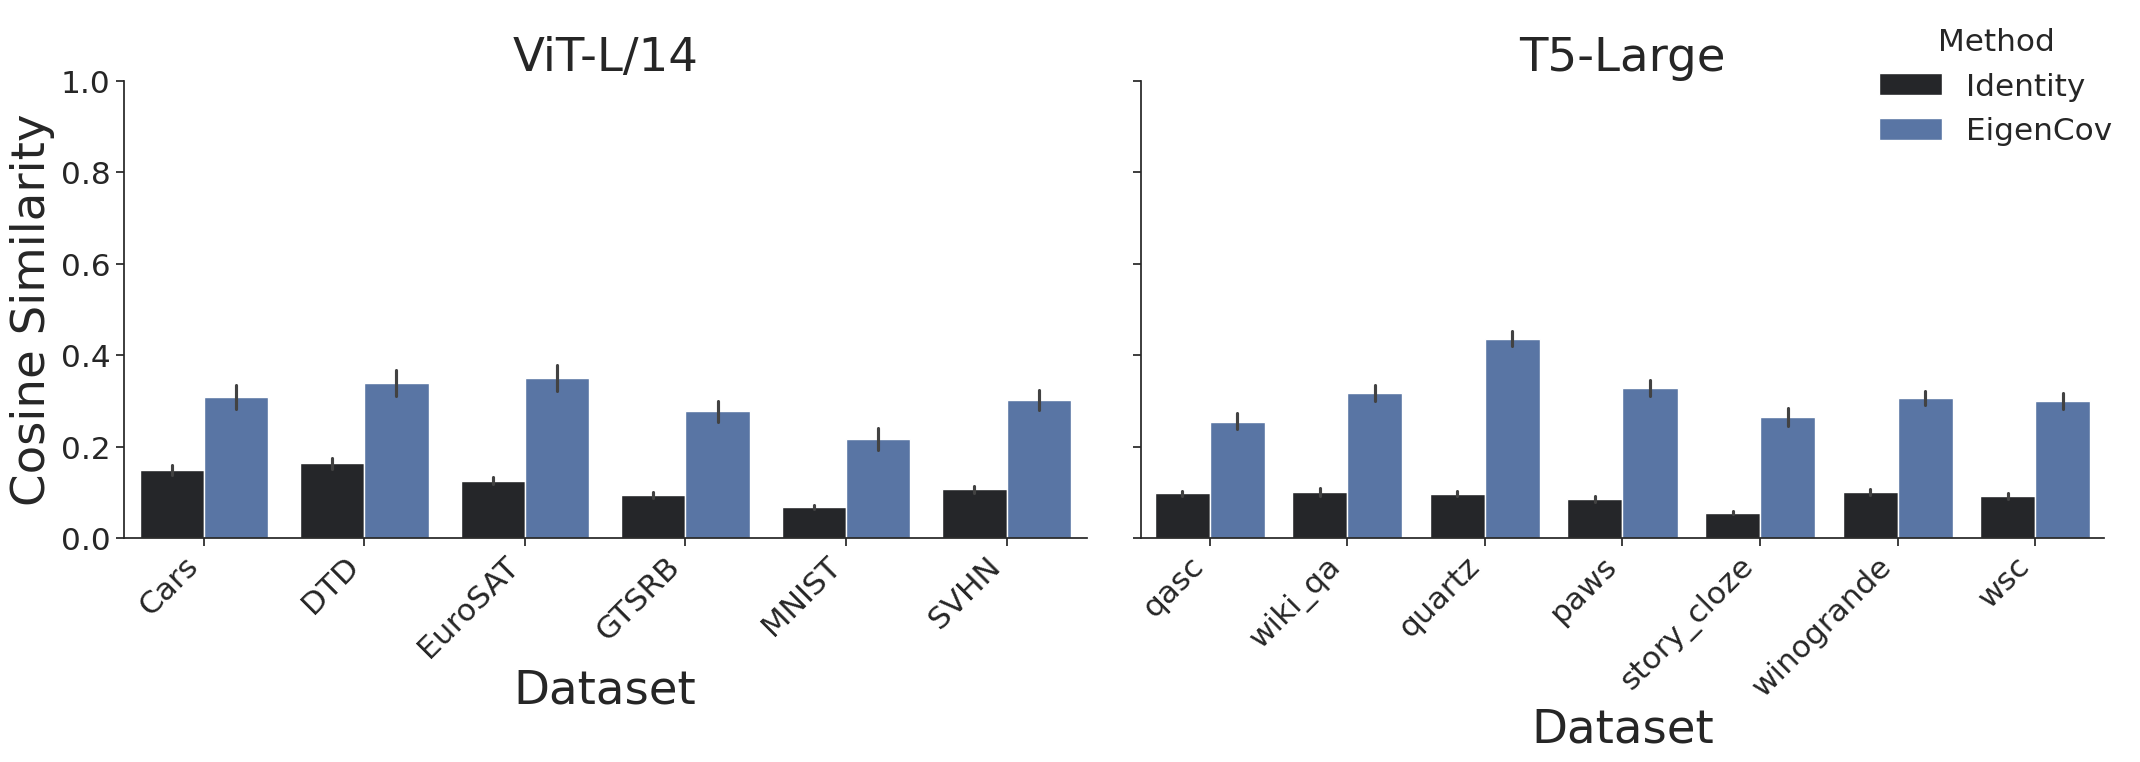

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)

g = sns.catplot(
    data=df, 
    x="dataset", 
    y="cos_sim", 
    kind="bar", 
    col="model", 
    col_order=["ViT-L/14", "T5-Large"], 
    sharey=True, 
    sharex=False,
    hue="method",
    hue_order=["Identity", "EigenCov"],
    palette='dark:#4c72b0',
    height=8,
    aspect=1.2
)
sns.move_legend(g, "upper right", title="Method")
g.set_axis_labels("Dataset", r"Cosine Similarity")
g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, ha="right")
plt.tight_layout()

# # print(f"Saved to: ../results-v1/{model}/correlation_violin.pdf")
# plt.savefig(os.path.join(RESULTS_DIR, "correlation_coeffs.pdf"), bbox_inches="tight")

/home/mila/m/marawan.gamal/scratch/eigcov/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/mila/m/marawan.gamal/scratch/eigcov/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


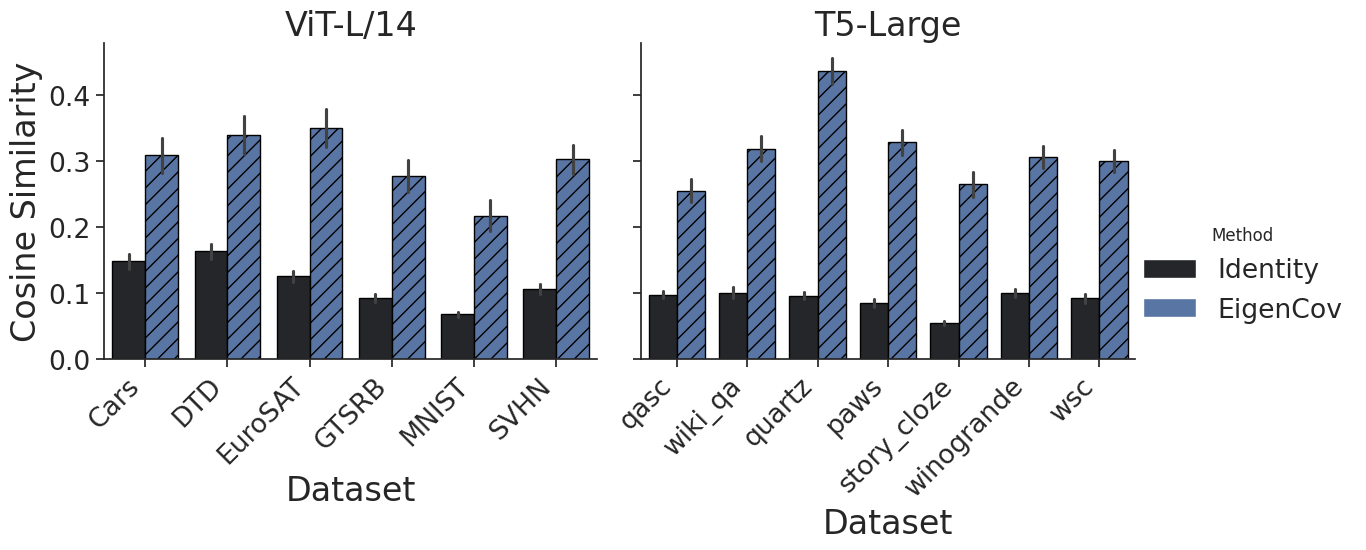

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BATCH_SIZE, NUM_SAMPLES = 32, 10
VISION_MODELS = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}
LANG_MODELS = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

def load_and_prep(path, model_map):
    df = pd.read_csv(path)
    df = df[(df["ft_method"] == "standard") & ~df["method"].isin(["Zeros", "Random"])]
    df["model"] = df["model"].map(model_map).fillna(df["model"])
    df["cos_sim"] = 1 - df["error"]
    return df

df = pd.concat([
    load_and_prep(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", VISION_MODELS),
    load_and_prep(f"../results/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", LANG_MODELS),
], ignore_index=True)

df = df[df["model"].isin(["ViT-L/14", "T5-Large"])]

BASE_FONTSIZE = 24
sns.set_theme(style="ticks", rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

g = sns.FacetGrid(df, col="model", col_order=["ViT-L/14", "T5-Large"], sharey=True, sharex=False, height=5, aspect=1.2)
g.map_dataframe(sns.barplot, x="dataset", y="cos_sim", hue="method", hue_order=["Identity", "EigenCov"])

# Add hatching per hue group
hatches = [None, "//"]
for ax in g.axes.flat:
    for container, hatch in zip(ax.containers, hatches):
        for bar in container:
            bar.set_hatch(hatch)
            bar.set_edgecolor("black")

g.set_axis_labels("Dataset", "Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=45, ha="right")
g.add_legend(title="Method")
g.figure.savefig("../results/eigcov_estimation_error_combined.pdf", dpi=300, bbox_inches="tight")


## Fig. 2a: (Assumption I) Cross-term Error

In [3]:
import pandas as pd
import torch
import os

def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())

# root_dir = "../checkpoints-gcm-e2/ViT-B-16/"
root_dir = "../checkpoints-accum-e2-v2-2026-06-15/ViT-B-16/max_steps_10"
DATASETS = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]

errors = []
for d in DATASETS:
    for filename in os.listdir(os.path.join(root_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace("grad_cross_matrix_model_visual_transformer_resblocks_", "")
        gcm = torch.load(os.path.join(root_dir, d + "Val", filename))
        # print(gcm['gbar'].shape, gcm['sbar'].shape)
        cosim = cosine_similarity(gcm['gbar'].T @ gcm['gbar'], gcm['sbar'])
        errors.append({"dataset": d, "layer_name": layer_name, "cosine_similarity": cosim.item()})

df = pd.DataFrame(errors)

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.DataFrame(errors)

# Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="dataset", y="angular_distance")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\theta$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_cross.pdf"), bbox_inches="tight")

KeyError: 'cosine_similarity'

## Fig. 2b: (Assumption II) Correlation Error


In [1]:
import pandas as pd
import torch
import os

def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())

# root_dir = "../checkpoints-gcm-e2/ViT-B-16/"
root_dir = "../checkpoints-accum-e2-v2-2026-06-15/ViT-B-16/max_steps_10"
DATASETS = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]

errors = []
for d in DATASETS:
    for filename in os.listdir(os.path.join(root_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace("grad_cross_matrix_model_visual_transformer_resblocks_", "")
        gcm = torch.load(os.path.join(root_dir, d + "Val", filename))
        # print(gcm['stilde'].shape, gcm['sbar'].shape)
        cosim = cosine_similarity(gcm['sbar'], gcm['stilde'])
        errors.append({"dataset": d, "layer_name": layer_name, "cosine_similarity": cosim.item()})

df = pd.DataFrame(errors)

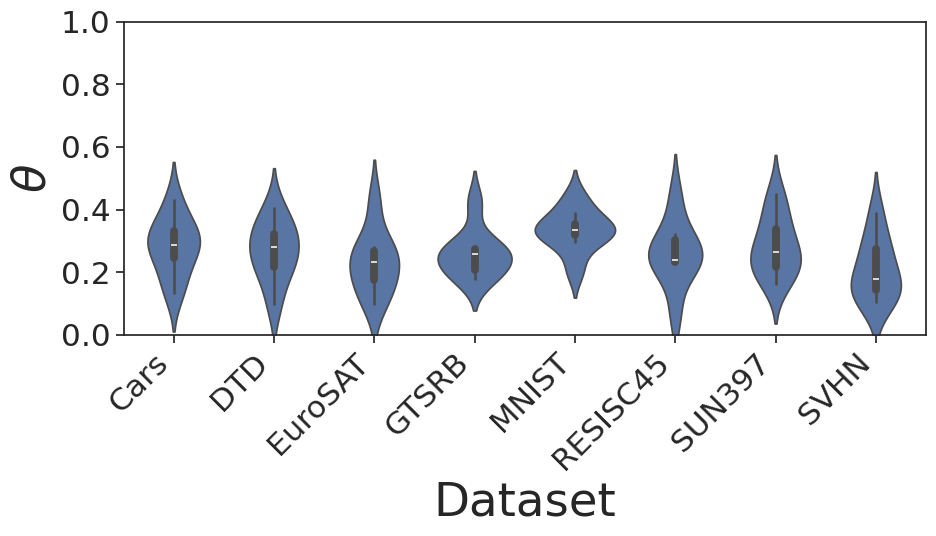

In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = "../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.DataFrame(errors)

# Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="dataset", y="angular_distance")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\theta$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_corr.pdf"), bbox_inches="tight")

## Fig. 2c: (Assumption III)  Drift Error

In [3]:
import pandas as pd
import torch
import os

def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())

root_dir = "../checkpoints-accum-e2-v2-2026-06-15/ViT-B-16/max_steps_10"
covs_dir = f"{root_dir}/covariances_strain_n10_b32_tsm_attnsplit_efull_ftstandard"
DATASETS = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]


file2layer = lambda x: "image_encoder." + x.replace(".pt", "").replace("grad_cross_matrix_", "").replace("_", ".")
errors = []
for d in DATASETS:
    covs = np.load(f"{covs_dir}/covariance_{d}.npz")
    for filename in os.listdir(os.path.join(root_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace("grad_cross_matrix_model_visual_transformer_resblocks_", "")
        gcm = torch.load(os.path.join(root_dir, d + "Val", filename))
        cov = covs.get(file2layer(filename), None)
        if cov is None:
            continue
        cov = torch.from_numpy(cov)
        cosim = cosine_similarity(gcm['stilde'], cov)
        errors.append({"dataset": d, "layer_name": layer_name, "cosine_similarity": cosim.item(), "type": "stilde"})

df = pd.DataFrame(errors)

In [4]:
# # DEBUG
# rand = torch.randn_like(gcm['stilde']) * 0.00001
# print(cov.norm(), gcm['stilde'].norm(), rand.norm())
# print(cosine_similarity(gcm['stilde'], rand)) 
# print(cosine_similarity(gcm['stilde'], cov))
# tensor(31755.3848) tensor(0.0238) tensor(0.0077)
# tensor(-0.0020)
# tensor(0.9984)

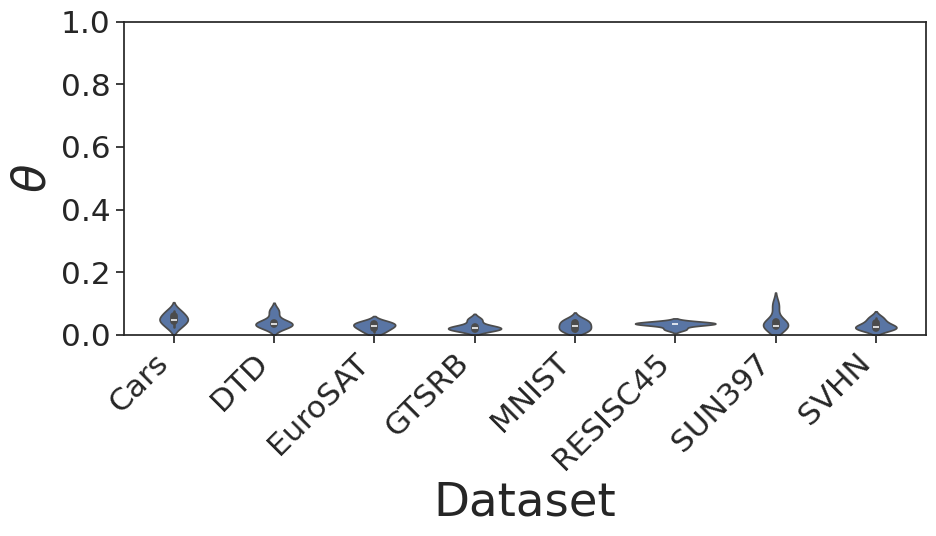

In [5]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.DataFrame(errors)

# Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="dataset", y="angular_distance")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\theta$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_drift.pdf"), bbox_inches="tight")

## Fig. 4a: (Assumption II)  Correlation between Gradients and Activations


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from itertools import product

sns.set_theme()
BASE_FONTSIZE=28

model = "ViT-B-16"
batch_size = 1
num_samples = 100
num_indices = 32
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ft_methods = ["standard"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task, ft_method in product(tasks, ft_methods):
    corr_dir = f"../results/{model}/correlations_b{batch_size}_n{num_samples}_k{num_indices}_ft{ft_method}"
    path = f"{corr_dir}/correlation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    # remove "g_sq/" prefix
    layers = [k[5:] for k in data.files if k.startswith("g_sq/")]
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        for idx_i in range(N_indices):
            rho = np.abs(corr(g, aat[:, idx_i]))
            rows.append({'task': task, 'layer': l, 'layer_idx': idx_l, 'entry_idx': idx_i, 'rho': rho, 'ft_method': ft_method})

df = pd.DataFrame(rows)
# # Print summary
# print("\nSummary Statistics (all points):")
# print(df.groupby('task')['rho'].describe()[['mean', 'std', '50%', 'max']].round(3).to_string())
# print(f"\nOverall mean |ρ|: {df['rho'].mean():.3f}")
# print(f"% of all correlations < 0.1: {(df['rho'] < 0.1).mean() * 100:.1f}%")


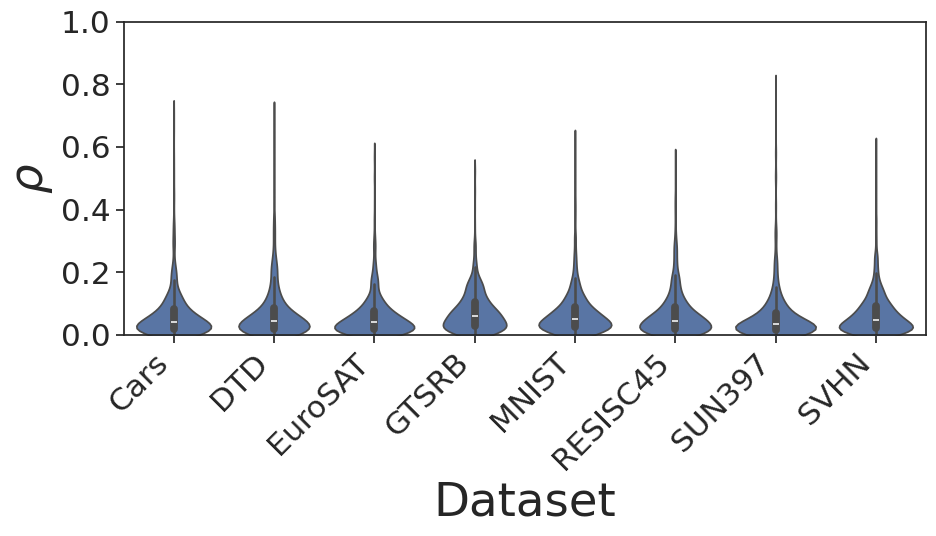

In [27]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="task", y="rho")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\rho$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# # print(f"Saved to: ../results-v1/{model}/correlation_violin.pdf")
plt.savefig(os.path.join(RESULTS_DIR, "correlation_coeffs.pdf"), bbox_inches="tight")

## Fig. 4b: (Assumption III) Covariance Stationarity

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
MAX_CKPT = 10


def cosine_similarity(A, B):
    a, b = torch.tensor(A).flatten().float(), torch.tensor(B).flatten().float()
    return (torch.dot(a, b) / (a.norm() * b.norm())).item()

# Find all checkpoint dirs and extract their numbers
ckpt_dirs = sorted(
    (int(d.split("checkpoint_")[-1]), d)
    for d in os.listdir(RESULTS_DIR)
    if "checkpoint_" in d and "covariance" in d
)[:MAX_CKPT]

ref_num, ref_dir = ckpt_dirs[-1]
print(f"Checkpoints: {[n for n, _ in ckpt_dirs]}, reference: {ref_num}")

rows = []
for dataset in tqdm(DATASETS, desc="Datasets"):
    ref = np.load(f"{RESULTS_DIR}/{ref_dir}/covariance_{dataset}.npz", allow_pickle=True)
    covs_accum = dict()

    for ckpt_num, ckpt_dir in tqdm(ckpt_dirs, desc=dataset, leave=False):
        path = f"{RESULTS_DIR}/{ckpt_dir}/covariance_{dataset}.npz"
        if not os.path.exists(path):
            continue
        covs = np.load(path, allow_pickle=True)
        for layer in ref.files:
            if layer in covs and covs[layer].ndim == 2:
                if layer not in covs_accum:
                    covs_accum[layer] = np.zeros_like(covs[layer])
                covs_accum[layer] += covs[layer]
                rows.append({
                    "checkpoint": ckpt_num,
                    "dataset": dataset,
                    "layer": layer,
                    "cosine_similarity": cosine_similarity(covs[layer], ref[layer]),
                    "cosine_similarity_accum": cosine_similarity(covs_accum[layer], ref[layer]),
                })

df = pd.DataFrame(rows)
df.to_csv(f"{RESULTS_DIR}/covariance_stationarity.csv", index=False)
print(df.groupby("checkpoint")["cosine_similarity"].mean())

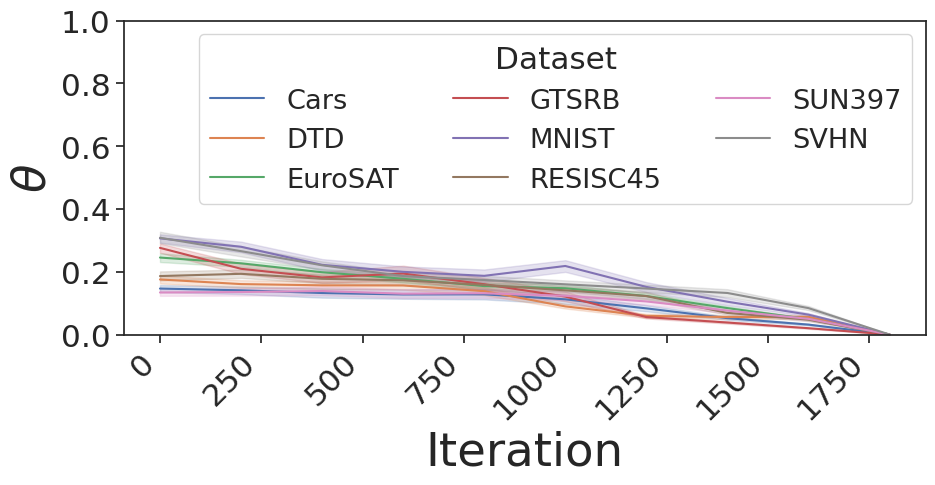

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = f"../results/ViT-B-16"

df = pd.read_csv(f"{RESULTS_DIR}/covariance_stationarity.csv")
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 
df["angular_distance_accum"] = np.arccos(df["cosine_similarity_accum"].clip(-1.0, 1.0)) / np.pi 


BASE_FONTSIZE = 28
sns.set_theme(
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.7,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=df, x="checkpoint", y="angular_distance", hue="dataset")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\theta$")
plt.xlabel("Iteration")
plt.legend(title="Dataset", loc="upper right", ncol=3, frameon=True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_drift_trajectory.pdf"), bbox_inches="tight")

## Fig. 5: Accuracy vs. Number of Samples used for Covariance Estimation

In [2]:
import json
import re
import pandas as pd

with open("../results-v1/results.jsonl") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())

rm = df[df["merge_func"] == "regmean"].copy()
rm = rm[['model', 'finetuning_mode', 'cov_dir', 'test_avg_top1']]
display(rm)
# rm["n_batches"] = rm["cov_dir"].str.extract(r"_n(\d+)_")[0].astype(int)
# rm["batch_size"] = rm["cov_dir"].str.extract(r"_b(\d+)_")[0].astype(int)
# rm["n_samples"] = rm["n_batches"] * rm["batch_size"]
# display(rm[["model", "finetuning_mode", "n_batches", "batch_size", "n_samples", "test_avg_top1", "test_avg_normalized_top1"]])

,model,finetuning_mode,cov_dir,test_avg_top1
1,ViT-B-16,lora,results/ViT-B-16/covariances_strain_n10_b32_ts...,0.803967
12,ViT-B-32,lora,results/ViT-B-32/covariances_strain_n10_b32_ts...,0.762208
37,ViT-B-16,standard,results/ViT-B-16/covariances_strain_n10_b32_ts...,0.870506
38,ViT-B-32,standard,results/ViT-B-32/covariances_strain_n10_b32_ts...,0.831229
39,ViT-L-14,standard,results/ViT-L-14/covariances_strain_n10_b32_ts...,0.901043
45,ViT-L-14,lora,results/ViT-L-14/covariances_strain_n10_b32_ts...,0.869147
53,t5-base,standard,results/t5-base/covariances_strain_n10_b32_tsm...,0.745286
54,t5-large,standard,results/t5-large/covariances_strain_n10_b32_ts...,0.808429
65,t5-base,lora,results/t5-base/covariances_strain_n10_b32_tsm...,0.739857
69,ViT-B-16,standard,results/ViT-B-16/covariances_eigcov_k1000_ftst...,0.794086


In [11]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
with open("../results/results.jsonl") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())

# Parse n_samples from cov_dir string
df["n_batches"] = df["cov_dir"].str.extract(r"_n(\d+)_")[0].astype("Int64")
df["batch_size"] = df["cov_dir"].str.extract(r"_b(\d+)_")[0].astype("Int64")
df["n_samples"] = df["n_batches"] * df["batch_size"]
df["cov_estimator"] = df["cov_dir"].str.extract(r"_e(sampled|full)")[0]                                                                                                 
df["cov_attn"] = df["cov_dir"].str.extract(r"_attn(split|None)")[0] 
df["cov_type"] = df["cov_dir"].str.extract(r"_t(sm|cov)")[0] 


# Filter: keep only RegMean and EigCov
df = df[df["merge_func"].isin(["regmean", "eigcov"])]
# Filter: keep only ViT-B-16
df = df[df["model"] == "ViT-B-16"]
# Filter: keep only standard finetuning
df = df[df["finetuning_mode"] == "standard"]
# Filter: remove faulty records
df = df[df["cov_attn"].fillna("None") == df["mha"].fillna("None")]
# Make many rows for EigCov
eigcov_row = df[df["merge_func"] == "eigcov"].iloc[0].copy()
df = df[df["merge_func"] != "eigcov"]
for n in [1, 10, 100, 500, 1000]:
    eigcov_row["n_samples"] = n
    eigcov_row["batch_size"] = 1
    df = pd.concat([df, eigcov_row.to_frame().T], ignore_index=True)
# Filter: keep only batch size 1
df = df[(df["batch_size"] == 1)]
# Display
# Filter: keep only 500 samples
df = df[df["n_samples"] == 500]
# Filter: keep only important columns
df = df[["model", "merge_func", "finetuning_mode", "n_samples", "n_batches", "batch_size", "cov_estimator", "cov_attn", "cov_type", "test_avg_top1"]]
display(df)

# df = df[df["merge_func"].isin(["regmean", "eigcov"]) & (df["model"] == "ViT-B-16")]
# df["Method"] = df["merge_func"].map({"regmean": "RegMean", "eigcov": "EigCov"})

# # Filter and rename
# print(df[df["Method"] == "EigCov"][["Model", "Method", "n", "batch_size", "Accuracy", "merge_func", "cov_dir"]])

# df = df[(df["batch_size"] == 1) | (df["Method"] == "EigCov")]
# df = df.rename(columns={"model": "Model", "test_avg_top1": "Accuracy", "n_samples": "n"})
# df = df[["Model", "Method", "n", "Accuracy"]]

# # Replicate EigCov across RegMean n values for flat reference line
# n_values = sorted(df.loc[df["Method"] == "RegMean", "n"].unique())
# eigcov_flat = df[df["Method"] == "EigCov"].drop(columns="n").merge(
#     pd.DataFrame({"n": n_values}), how="cross"
# )
# df = pd.concat([df[df["Method"] == "RegMean"], eigcov_flat], ignore_index=True)
# display(df)

# sns.set_theme()
# sns.lineplot(data=df, x="n_samples", y="test_avg_top1", hue="model", style="merge_func")
#             #  dashes={"RegMean": "", "EigCov": (4, 2)})
# plt.savefig("../results/acc_vs_n.pdf", dpi=300, bbox_inches="tight")
# plt.show()

/tmp/ipykernel_4183782/3743755002.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, eigcov_row.to_frame().T], ignore_index=True)
/tmp/ipykernel_4183782/3743755002.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, eigcov_row.to_frame().T], ignore_index=True)
/tmp/ipykernel_4183782/3743755002.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty o

,model,merge_func,finetuning_mode,n_samples,n_batches,batch_size,cov_estimator,cov_attn,cov_type,test_avg_top1
6,ViT-B-16,regmean,standard,500,500,1,full,split,sm,0.860047
11,ViT-B-16,regmean,standard,500,500,1,sampled,split,sm,0.858132
16,ViT-B-16,regmean,standard,500,500,1,sampled,None,sm,0.816467
21,ViT-B-16,eigcov,standard,500,<NA>,1,NaN,NaN,NaN,0.878577


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Data ─────────────────────────────────────────────────────────────────
N = [1, 10, 25, 50, 75, 200, 320, 500]

RESULTS = {
    # ("ViT-B-16", "RegMean"): [0.728, 0.824, 0.847, 0.863, 0.864, 0.871, 0.871, 0.875],
    # ("ViT-B-16", "EigCov"):  [0.87] * len(N),
    ("T5-Large", "RegMean"): [...],
    ("T5-Large", "EigCov"):  [...],
}
# ─────────────────────────────────────────────────────────────────────────

df = pd.DataFrame([
    {"Model": m, "Method": mt, "n": n, "Accuracy": a}
    for (m, mt), accs in RESULTS.items()
    for n, a in zip(N, accs)
])
sns.set_theme()
sns.lineplot(data=df, x="n", y="Accuracy", hue="Model", style="Method",
             dashes={"RegMean": "", "EigCov": (4, 2)}, markers=True)
plt.savefig("../results/acc_vs_n.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Fig. 6: RegMean vs. EigCov estimation

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
FT_METHOD = "standard"
BATCH_SIZE = 1
N_VALS = [1, 10, 100, 500, 1000]
N_MAX = max(N_VALS)
K_VALS = [8, 32, 64]
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")

rows = []
for task in tqdm(TASKS, desc="Tasks"):
    target_path = f"{RESULTS_DIR}/covariances_strain_n{N_MAX}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
    if not os.path.exists(target_path):
        print(f"Missing target: {target_path}")
        continue
    target_covs = np.load(target_path, allow_pickle=True)

    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/finetuned.pt"
    tv = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)

    layers = [(k, m) for k, m in tv.vector.items() if len(m.shape) == 2 and param_name_to_module_name(k) in target_covs]
    for key, d in tqdm(layers, desc=f"  {task} layers", leave=False):
        kp = param_name_to_module_name(key)
        c_target = torch.from_numpy(target_covs[kp]).float()
        c_ec = (d.T @ d).float()

        for n in N_VALS:
            cov_path = f"{RESULTS_DIR}/covariances_strain_n{n}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
            if not os.path.exists(cov_path):
                print(f"Missing: {cov_path}")
                continue
            covs = np.load(cov_path, allow_pickle=True)
            if kp not in covs:
                continue
            c_rm = torch.from_numpy(covs[kp]).float()

            for kk in K_VALS:
                rows.append({"task": task, "layer": key, "n": n, "k": kk, "method": "RegMean", "error": dist_fn(c_rm, c_target, kk)})
                rows.append({"task": task, "layer": key, "n": n, "k": kk, "method": "EigenCov", "error": dist_fn(c_ec, c_target, kk)})

df_est = pd.DataFrame(rows)
print(df_est.groupby(["method", "n", "k"])["error"].mean().unstack("method"))


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys

# Add src to path
sys.path.append("..")

from src.vision.task_vectors import NonLinearTaskVector

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
FT_METHOD = "standard"
BATCH_SIZE = 1
N_VALS = [1, 10, 100, 500, 1000]
N_MAX = max(N_VALS)
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")

def frob_error(C, C_target):
    """||C_target - C||_F / ||C_target||_F"""
    diff = torch.linalg.norm(C_target - C, ord="fro")
    norm = torch.linalg.norm(C_target, ord="fro")
    return (diff / norm).item() if norm > 1e-12 else float("nan")

rows = []
for task in tqdm(TASKS, desc="Tasks"):
    # Load target covariance (largest n)
    target_path = f"{RESULTS_DIR}/covariances_strain_n{N_MAX}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
    if not os.path.exists(target_path):
        print(f"Missing target: {target_path}")
        continue
    target_covs = np.load(target_path, allow_pickle=True)

    # Load task vector and compute c_ec = M.T @ M (constant across n)
    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/finetuned.pt"
    tv = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)

    layers = [(k, m) for k, m in tv.vector.items() if len(m.shape) == 2 and param_name_to_module_name(k) in target_covs]
    for k, d in tqdm(layers, desc=f"  {task} layers", leave=False):
        kp = param_name_to_module_name(k)
        c_target = torch.from_numpy(target_covs[kp]).float()
        c_ec = (d.T @ d).float()
        ec_err = frob_error(c_ec, c_target)

        for n in N_VALS:
            cov_path = f"{RESULTS_DIR}/covariances_strain_n{n}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
            if not os.path.exists(cov_path):
                print(f"Missing: {cov_path}")
                continue
            covs = np.load(cov_path, allow_pickle=True)
            if kp not in covs:
                continue
            c_rm = torch.from_numpy(covs[kp]).float()
            rows.append({"task": task, "layer": k, "n": n, "method": "RegMean", "error": frob_error(c_rm, c_target)})
            rows.append({"task": task, "layer": k, "n": n, "method": "EigenCov", "error": ec_err})

df_est = pd.DataFrame(rows)
print(df_est.groupby(["method", "n"])["error"].mean().unstack("method"))


Tasks:   0%|          | 0/8 [00:00<?, ?it/s]

  Cars layers:   0%|          | 0/24 [00:00<?, ?it/s]

  DTD layers:   0%|          | 0/24 [00:00<?, ?it/s]

  EuroSAT layers:   0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
BASE_FONTSIZE = 24

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

df_plot = df_est.groupby(["method", "n", "k"])["error"].mean().reset_index()

# EigenCov is constant across n; plot as horizontal dashed line per k facet
palette = {"RegMean": sns.color_palette()[0], "EigenCov": sns.color_palette()[1]}

g = sns.relplot(
    data=df_plot[df_plot["method"] == "RegMean"],
    x="n", y="error",
    col="k",
    kind="line",
    markers=True,
    label="RegMean",
    color=palette["RegMean"],
    facet_kws={"sharey": False, "legend_out": True},
)

# Add EigenCov as a horizontal dashed line per facet
for ax, kk in zip(g.axes.flat, K_VALS):
    ec_err = df_plot[(df_plot["method"] == "EigenCov") & (df_plot["k"] == kk)]["error"].mean()
    ax.axhline(ec_err, linestyle="--", color=palette["EigenCov"], label="EigenCov")
    ax.set_xscale("log")
    ax.set_xticks(N_VALS)
    ax.set_xticklabels(N_VALS, rotation=45)

g.axes.flat[0].legend(title="Method")
g.set_axis_labels("Number of Samples ($n$)", "Grassmann Distance")
g.set_titles(col_template="k = {col_name}")

g.figure.savefig(f"{RESULTS_DIR}/regmean_vs_eigcov_grassmann_vs_n.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Fig. 8: Scaling Coeff Analysis

In [ ]:
import sys
import os
import math
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import LinearizedTaskVector, NonLinearTaskVector


MODELS = ["ViT-B-16"]
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
FT_METHODS = ["standard"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_scaling_coef_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
def dist_cos_noabs(A: torch.Tensor, B: torch.Tensor, *args, **kwargs) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    cos_theta = torch.dot(a, b) / (a.norm() * b.norm())
    return (1 - cos_theta)

max_layers_per_combo = MAX_LAYERS + 1 if MAX_LAYERS is not None else None
TOTAL = len(MODELS) * len(FT_METHODS) * len(DATASETS) * (max_layers_per_combo or 0)
global_step = 0

rows = []
for model_name in MODELS:
    results_dir = os.path.join(RESULTS_ROOT, model_name)
    checkpoint_dir = os.path.join(CHECKPOINTS_ROOT, model_name)
    # checkpoint_dir = f"../checkpoints/{model_name}"

    for ft_method, dataset in product(FT_METHODS, DATASETS):
        # Load covariance
        covs = np.load(f"{results_dir}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{ft_method}/covariance_{dataset}.npz", allow_pickle=True)

        # Load task vector
        if ft_method == "linear":
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/linear_zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/linear_finetuned.pt"
            pretrained_nonlinear_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"

            nonlinear_encoder = torch.load(
                pretrained_nonlinear_checkpoint, map_location="cpu", weights_only=False
            )
            param_names = [n for n, _ in nonlinear_encoder.named_parameters()]
            del nonlinear_encoder

            tv = LinearizedTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )
            encoder = tv.apply_to_nonlinear(
                pretrained_nonlinear_checkpoint, param_names, scaling_coef=1.0
            )
            task_vector = NonLinearTaskVector(
                vector=encoder.state_dict(),
            )
        elif ft_method == "lora":
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/lora_finetuned.pt"
            task_vector = NonLinearTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )
        else:
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/finetuned.pt"
            task_vector = NonLinearTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )

        task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

        num_added = 0
        if TOTAL == 0 and MAX_LAYERS is None:
            TOTAL = len(MODELS) * len(FT_METHODS) * len(DATASETS) * len(task_vector.vector)
        for k, d in task_vector.vector.items():
            kp = param_name_to_module_name(k)
            if len(d.shape) != 2 or kp not in covs.keys():
                continue
            d = d.to(DEVICE)
            c = torch.from_numpy(covs[kp]).to(d.dtype).to(DEVICE)
            c_hat_ec = d.T @ d
            kappa = torch.linalg.norm(c_hat_ec, ord="fro") / torch.linalg.norm(c, ord="fro")
            kappa_star = torch.trace(c.T @ c_hat_ec) / (torch.linalg.norm(c_hat_ec, ord="fro")**2)
            rows.append({
                "model": model_name, 
                "dataset": dataset, 
                "layer_name": k,
                "layer_idx": num_added, 
                "kappa": kappa_star.item(),
            })
            global_step += 1
            print(f"[{global_step}/{TOTAL}] {model_name} | {ft_method} | {dataset} | layer {num_added} | {k.split('.')[-2]} | Kappa: {kappa.item()}")
            num_added += 1
            if MAX_LAYERS is not None and num_added > MAX_LAYERS:
                break

# 0. Create a dataframe
df = pd.DataFrame(rows)

# 1. Create a "rho" dataframe by merging the results with itself 
# We join on 'model', 'layer_name', and 'layer_idx' to pair datasets for the same layer
df = df.merge(
    df, 
    on=['model', 'layer_name', 'layer_idx'], 
    suffixes=('_i', '_j')
)

# 2. Compute rho = kappa_i / kappa_j
df['rho'] = df['kappa_i'] / df['kappa_j']
df.to_csv(SAVE_PATH, index=False)

[1/1236] ViT-B-16 | standard | Cars | layer 0 | c_fc | Kappa: 2.2446427294653404e-07
[2/1236] ViT-B-16 | standard | Cars | layer 1 | c_proj | Kappa: 3.318279823361081e-06
[3/1236] ViT-B-16 | standard | Cars | layer 2 | c_fc | Kappa: 3.535502344220731e-07
[4/1236] ViT-B-16 | standard | Cars | layer 3 | c_proj | Kappa: 2.37345398090838e-06
[5/1236] ViT-B-16 | standard | Cars | layer 4 | c_fc | Kappa: 2.6565854227555974e-07
[6/1236] ViT-B-16 | standard | Cars | layer 5 | c_proj | Kappa: 2.5326285140181426e-06
[7/1236] ViT-B-16 | standard | Cars | layer 6 | c_fc | Kappa: 2.7991191586806963e-07
[8/1236] ViT-B-16 | standard | Cars | layer 7 | c_proj | Kappa: 3.7919000988040352e-06
[9/1236] ViT-B-16 | standard | Cars | layer 8 | c_fc | Kappa: 1.6989233131425863e-07
[10/1236] ViT-B-16 | standard | Cars | layer 9 | c_proj | Kappa: 3.0045373478060355e-06
[11/1236] ViT-B-16 | standard | Cars | layer 10 | c_fc | Kappa: 1.4683529059311695e-07
[12/1236] ViT-B-16 | standard | Cars | layer 11 | c_proj

In [55]:
display(df)

,model,dataset_i,layer_name,layer_idx,kappa_i,dataset_j,kappa_j,rho
0,ViT-B-16,Cars,model.visual.transformer.resblocks.0.mlp.c_fc....,0,743943.562500,Cars,7.439436e+05,1.000000
1,ViT-B-16,Cars,model.visual.transformer.resblocks.0.mlp.c_fc....,0,743943.562500,DTD,9.461962e+05,0.786247
2,ViT-B-16,Cars,model.visual.transformer.resblocks.0.mlp.c_fc....,0,743943.562500,EuroSAT,8.462981e+05,0.879056
3,ViT-B-16,Cars,model.visual.transformer.resblocks.0.mlp.c_fc....,0,743943.562500,GTSRB,1.043763e+06,0.712752
4,ViT-B-16,Cars,model.visual.transformer.resblocks.0.mlp.c_fc....,0,743943.562500,MNIST,6.904330e+05,1.077503
...,...,...,...,...,...,...,...,...
2587,ViT-B-16,SVHN,model.visual.transformer.resblocks.10.attn.o.w...,71,139245.328125,DTD,1.462735e+05,0.951952
2588,ViT-B-16,SVHN,model.visual.transformer.resblocks.10.attn.o.w...,71,139245.328125,EuroSAT,5.297492e+05,0.262851
2589,ViT-B-16,SVHN,model.visual.transformer.resblocks.10.attn.o.w...,71,139245.328125,GTSRB,1.617387e+05,0.860928
2590,ViT-B-16,SVHN,model.visual.transformer.resblocks.10.attn.o.w...,71,139245.328125,MNIST,1.439470e+05,0.967338


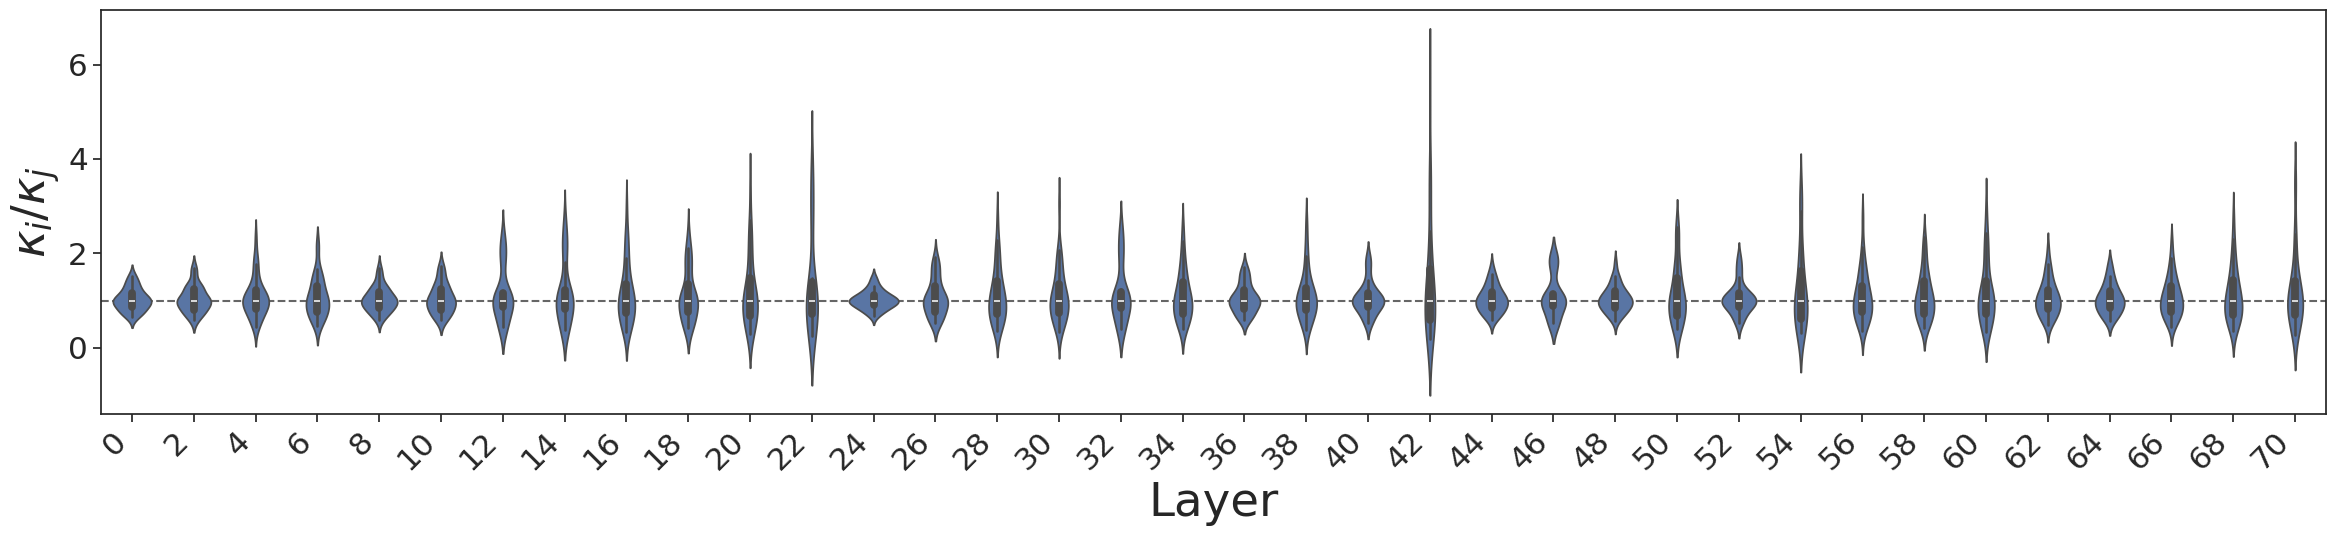

In [8]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results-v2"
CHECKPOINTS_ROOT = "../checkpoints-v2"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_scaling_coef_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

df = pd.read_csv(SAVE_PATH)

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.figure(figsize=(24, 6))
sns.violinplot(data=df[df["layer_idx"] % 2 == 0], x="layer_idx", y="rho")
plt.ylabel(r"$\kappa_i / \kappa_j$")
plt.xlabel("Layer")
plt.xticks(rotation=45, ha="right")
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "kappa-ratio-vs-layer.pdf"), bbox_inches="tight")

In [ ]:
import sys
import os
import math
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import LinearizedTaskVector, NonLinearTaskVector


MODELS = ["ViT-B-16"]
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
FT_METHODS = ["standard"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_scaling_coef_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
def dist_cos_noabs(A: torch.Tensor, B: torch.Tensor, *args, **kwargs) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    cos_theta = torch.dot(a, b) / (a.norm() * b.norm())
    return (1 - cos_theta)

def compute_merged_weights(W_ts, C_ts):
    numerator = sum(W_t @ C_t for W_t, C_t in zip(W_ts, C_ts))
    denominator = sum(C_ts)
    return numerator @ torch.linalg.pinv(denominator)

max_layers_per_combo = MAX_LAYERS + 1 if MAX_LAYERS is not None else None

for model_name in MODELS:
    results_dir = os.path.join(RESULTS_ROOT, model_name)
    checkpoint_dir = os.path.join(CHECKPOINTS_ROOT, model_name)

    ft_method = FT_METHODS[0]

    # Load all task vectors and covariances
    all_covs = {}
    all_tvs = {}
    for dataset in DATASETS:
        covs = np.load(f"{results_dir}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{ft_method}/covariance_{dataset}.npz", allow_pickle=True)

        pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
        finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/finetuned.pt"
        task_vector = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)
        task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

        all_covs[dataset] = covs
        all_tvs[dataset] = task_vector

    # Organize per-layer data
    first_tv = all_tvs[DATASETS[0]]
    layer_data = []
    for k, d in first_tv.vector.items():
        kp = param_name_to_module_name(k)
        if len(d.shape) != 2 or kp not in all_covs[DATASETS[0]].keys():
            continue

        W_ts, C_ts, C_hat_ts = [], [], []
        for dataset in DATASETS:
            d = all_tvs[dataset].vector[k].to(DEVICE).double()
            c = torch.from_numpy(all_covs[dataset][kp]).to(DEVICE).double()
            W_ts.append(d)
            C_ts.append(c)
            C_hat_ts.append(d.T @ d)

        W_star_true = compute_merged_weights(W_ts, C_ts)
        layer_data.append({"W_ts": W_ts, "C_ts": C_ts, "C_hat_ts": C_hat_ts, "W_star_true": W_star_true})

        if MAX_LAYERS is not None and len(layer_data) > MAX_LAYERS:
            break

    T = len(DATASETS)

    # Optimize kappas with torch autograd
    # kappa_1 = 1 fixed, optimize kappa_2, ..., kappa_T
    kappas_free = torch.ones(T - 1, device=DEVICE, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([kappas_free], lr=1e-2)

    for step in tqdm(range(5000), desc="Optimizing kappas", leave=False):
        optimizer.zero_grad()
        kappas = torch.cat([torch.ones(1, device=DEVICE, dtype=torch.float64), kappas_free])

        loss = torch.tensor(0.0, device=DEVICE, dtype=torch.float64)
        for ld in layer_data:
            scaled = [kappas[t] * ld["C_hat_ts"][t] for t in range(T)]
            W_est = compute_merged_weights(ld["W_ts"], scaled)
            loss = loss + torch.sum((ld["W_star_true"].detach() - W_est) ** 2)

        loss.backward()
        optimizer.step()

        if step % 500 == 0:
            print(f"Step {step}: loss = {loss.item():.6f}, kappas = {kappas.detach().cpu().numpy()}")

    # Final results
    optimal_kappas = torch.cat([torch.ones(1, device=DEVICE, dtype=torch.float64), kappas_free]).detach().cpu().numpy()
    
    # Baseline: all kappas = 1
    with torch.no_grad():
        baseline_loss = 0.0
        for ld in layer_data:
            W_est = compute_merged_weights(ld["W_ts"], ld["C_hat_ts"])
            baseline_loss += torch.sum((ld["W_star_true"] - W_est) ** 2).item()

    print(f"\nBaseline loss (all kappa=1): {baseline_loss:.6f}")
    print(f"Optimal loss: {loss.item():.6f}")
    print(f"Optimal kappas: {optimal_kappas}")
    print(f"Reduction: {100 * (baseline_loss - loss.item()) / baseline_loss:.2f}%")

Optimizing kappas:   0%|          | 1/5000 [05:03<421:48:08, 303.76s/it]

Step 0: loss = 128647584.566661, kappas = [1. 1. 1. 1. 1. 1.]


## Fig. 9: Distance Between Estimators

In [11]:
import sys
import os
import math
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import  NonLinearTaskVector

pinv = torch.linalg.pinv

MODEL = "ViT-B-16"
FT_METHOD = "standard"
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_scaling_coef_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
MAX_DIM = 10_000
RESULTS_DIR = os.path.join(RESULTS_ROOT, MODEL)
CHECKPOINTS_DIR = os.path.join(CHECKPOINTS_ROOT, MODEL)

tvs = []
for dataset in DATASETS:
    pretrained_checkpoint = f"{CHECKPOINTS_DIR}/{dataset}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINTS_DIR}/{dataset}Val/finetuned.pt"
    tvs.append(NonLinearTaskVector(
        pretrained_checkpoint,
        finetuned_checkpoint,
        lazy=True,
        covariance_path=f"{RESULTS_DIR}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{dataset}.npz",
    ))

# mhas
tvs = [t.map( mhas.copy_from_pytorch_state_dict) for t in tvs]

total = len(DATASETS) * len(tvs[0].vector)
global_step = 0
num_added = 0
rows = []

# Loop over layers
for j, key in enumerate(tvs[0].vector.keys()):
    if j < 10:
        continue
    if any(key not in v.vector for v in tvs):
        print(f"[{global_step}/{total}] {key} (skipped)")
        continue

    tau = torch.stack([v.get_vector_element(key).to(DEVICE) for v in tvs])
    if (
        tau[0].ndim != 2
        or "text_projection" in key
        or max(tau[0].shape) >= MAX_DIM
    ):
        global_step += 1
        print(f"[{global_step}/{total}] {key} (skipped)")
        continue
    
    # Get all covs for layer
    c = []
    for v in tvs:
        km = v.param_key_to_cov_key(key)
        cpath = v.covariance_path
        if cpath is None:
            raise ValueError(f"No covariance path provided for task vector {v}")
        with np.load(cpath) as cdict:
            if km not in cdict:
                print(f"[skipped] {km} not found in {cpath}")
                global_step += 1
                continue
            ct = cdict[km]
            c.append(ct)
    c_emp = torch.stack([torch.as_tensor(x, device=tau.device, dtype=tau.dtype) for x in c])
    c_hat = tau.transpose(1, 2) @ tau
    w_star_emp = (tau @ c_emp).sum(dim=0) @ pinv(c_emp.sum(dim=0))
    w_star_hat = (tau @ c_hat).sum(dim=0) @ pinv(c_hat.sum(dim=0))
    rows.append({
        "model": MODEL,
        "layer_name": key,
        "layer_idx": num_added,
        "error": torch.linalg.norm(w_star_emp - w_star_hat, ord=2),
        "error_rel": torch.linalg.norm(w_star_emp - w_star_hat, ord=2) / torch.linalg.norm(w_star_emp, ord=2),
    })
    num_added += 1
    global_step += 1
    print(f"[{global_step}/{len(tvs[0].vector)}] {key} (added)")

df = pd.DataFrame(rows)

[1/1236] model.visual.transformer.resblocks.0.ln_1.bias (skipped)
[2/1236] model.visual.transformer.resblocks.0.ln_2.weight (skipped)
[3/1236] model.visual.transformer.resblocks.0.ln_2.bias (skipped)
[1/206] model.visual.transformer.resblocks.0.mlp.c_fc.weight (added)
[5/1236] model.visual.transformer.resblocks.0.mlp.c_fc.bias (skipped)
[2/206] model.visual.transformer.resblocks.0.mlp.c_proj.weight (added)
[7/1236] model.visual.transformer.resblocks.0.mlp.c_proj.bias (skipped)
[8/1236] model.visual.transformer.resblocks.1.ln_1.weight (skipped)
[9/1236] model.visual.transformer.resblocks.1.ln_1.bias (skipped)
[10/1236] model.visual.transformer.resblocks.1.ln_2.weight (skipped)
[11/1236] model.visual.transformer.resblocks.1.ln_2.bias (skipped)
[3/206] model.visual.transformer.resblocks.1.mlp.c_fc.weight (added)
[13/1236] model.visual.transformer.resblocks.1.mlp.c_fc.bias (skipped)
[4/206] model.visual.transformer.resblocks.1.mlp.c_proj.weight (added)
[15/1236] model.visual.transformer.re

KeyboardInterrupt: 

<Axes: xlabel='layer_idx', ylabel='error_rel'>

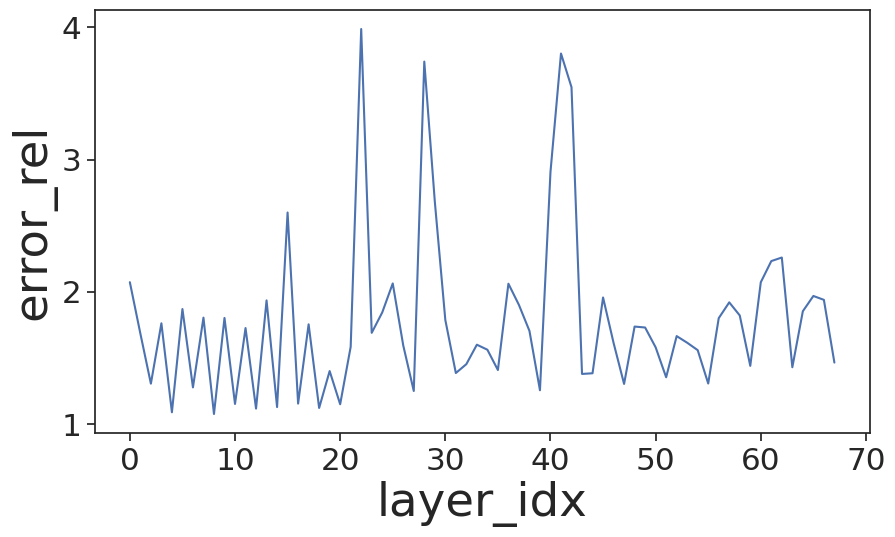

In [21]:
# # Save 
# df = pd.DataFrame(rows)
# df.to_csv(os.path.join(RESULTS_DIR, "parameter_difference_vs_layer.csv"), index=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = f"../results/ViT-B-16"

df = pd.read_csv(os.path.join(RESULTS_DIR, "parameter_difference_vs_layer.csv"))
df['error_rel'] = df['error_rel'].str.extract(r'tensor\(([^,]+)').astype(float)

BASE_FONTSIZE = 28
sns.set_theme(
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE * 1.2,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.7,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=df, x="layer_idx", y="error_rel")
# plt.ylim(0, 1)  # Set y-axis range from 0 to 1
# plt.ylabel(r"$\theta$")
# plt.xlabel("Iteration")
# plt.legend(title="Dataset", loc="upper right", ncol=3, frameon=True)
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_drift_trajectory.pdf"), bbox_inches="tight")

In [ ]:
# df['error_rel'] = df['error_rel'].str.extract(r'tensor\(([^,]+)').astype(float)
# >> "tensor(2.0716, device='cuda:0')"

0     2.0716
1     1.6826
2     1.3036
3     1.7604
4     1.0871
       ...  
63    1.4279
64    1.8520
65    1.9673
66    1.9380
67    1.4631
Name: error_rel, Length: 68, dtype: float64

## Fig. 10: NLG Analysis

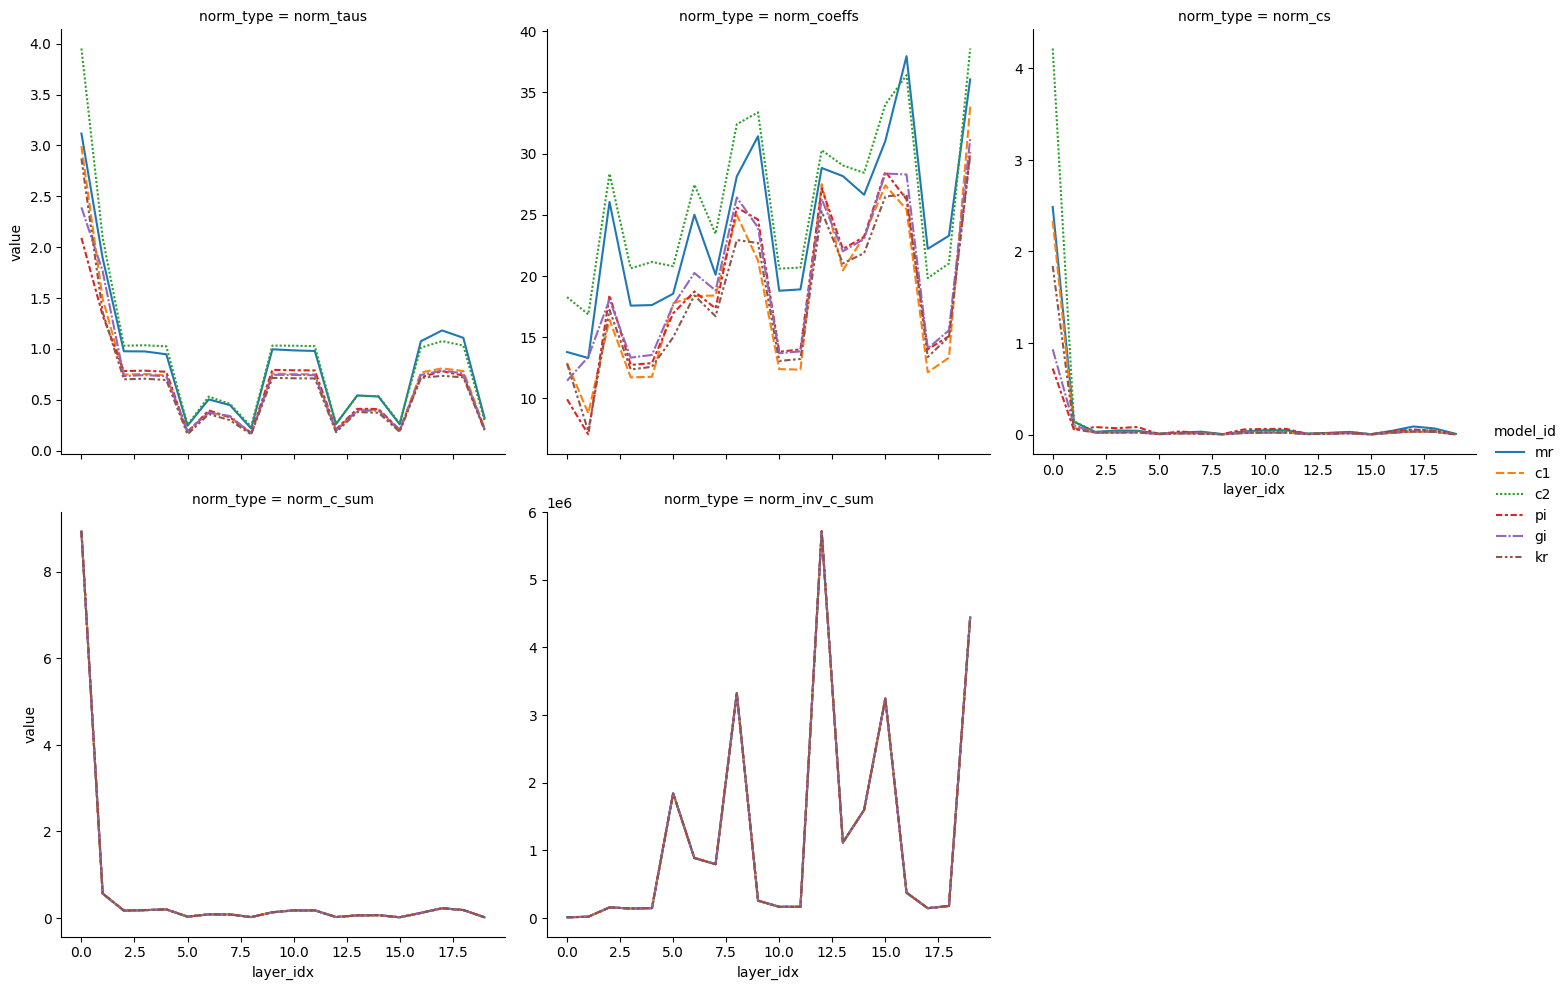

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../results/nlg_coeffs.csv")

MODEL_MAP = {
    "pmahdavi-Llama-3.1-8B-coding": "c1",
    "pmahdavi-Llama-3.1-8B-coding-tulu3-ebs128-lr5e6-wsdcr0p4": "c2",
    "pmahdavi-Llama-3.1-8B-math-reasoning": "mr",
    "pmahdavi-Llama-3.1-8B-precise-if": "pi",
    "pmahdavi-Llama-3.1-8B-knowledge-recall": "kr",
    "pmahdavi-Llama-3.1-8B-general": "gi",
}

df["model_id"] = df["model_id"].map(MODEL_MAP)

norm_cols = ["norm_taus", "norm_coeffs", "norm_cs", "norm_c_sum", "norm_inv_c_sum"]

df_melted = df.melt(
    id_vars=["layer_idx", "model_id"],
    value_vars=norm_cols,
    var_name="norm_type",
    value_name="value",
)

sns.relplot(
    data=df_melted,
    x="layer_idx",
    y="value",
    hue="model_id",
    style="model_id",
    col="norm_type",
    kind="line",
    col_wrap=3,
    facet_kws={"sharey": False},
)
plt.show()

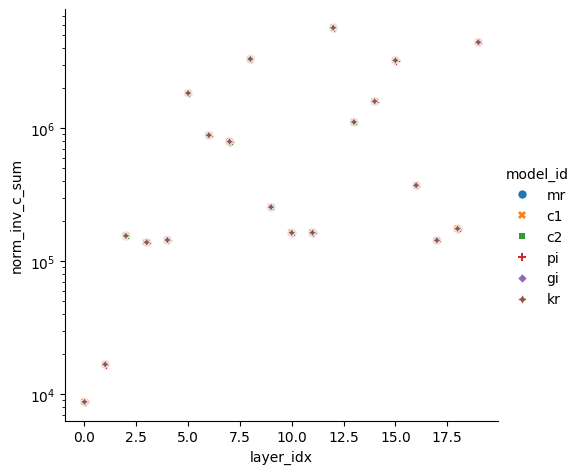

In [20]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("../results/nlg_coeffs.csv")
# print(df.to_string())

MODEL_MAP = {
    "pmahdavi-Llama-3.1-8B-coding": "c1",
    "pmahdavi-Llama-3.1-8B-coding-tulu3-ebs128-lr5e6-wsdcr0p4": "c2",
    "pmahdavi-Llama-3.1-8B-math-reasoning": "mr",
    "pmahdavi-Llama-3.1-8B-precise-if": "pi",
    "pmahdavi-Llama-3.1-8B-knowledge-recall": "kr",
    "pmahdavi-Llama-3.1-8B-general": "gi",
}

# norm_taus
# norm_coeffs
# norm_cs
# norm_c_sum
# norm_inv_c_sum

df["model_id"] = df["model_id"].map(MODEL_MAP)
# sns.relplot(data=df, x="layer_idx", y="norm_inv_c_sum", hue="model_id", style="model_id")
g = sns.relplot(
    data=df,
    x="layer_idx",
    y="norm_inv_c_sum",
    hue="model_id",
    style="model_id"
)
g.set(yscale="log")
plt.show()



In [19]:
import sys
import os
import math
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import  NonLinearTaskVector

pinv = torch.linalg.pinv

MODEL = "ViT-B-16"
FT_METHOD = "standard"
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_scaling_coef_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
MAX_DIM = 10_000
RESULTS_DIR = os.path.join(RESULTS_ROOT, MODEL)
CHECKPOINTS_DIR = os.path.join(CHECKPOINTS_ROOT, MODEL)

tvs = []
for dataset in DATASETS:
    pretrained_checkpoint = f"{CHECKPOINTS_DIR}/{dataset}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINTS_DIR}/{dataset}Val/finetuned.pt"
    tvs.append(NonLinearTaskVector(
        pretrained_checkpoint,
        finetuned_checkpoint,
        lazy=True,
        covariance_path=f"{RESULTS_DIR}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{dataset}.npz",
    ))

# mhas
tvs = [t.map( mhas.copy_from_pytorch_state_dict) for t in tvs]

total = len(DATASETS) * len(tvs[0].vector)
global_step = 0
num_added = 0
rows = []

# Loop over layers
for j, key in enumerate(tvs[0].vector.keys()):
    if j < 10:
        continue
    if any(key not in v.vector for v in tvs):
        print(f"[{global_step}/{total}] {key} (skipped)")
        continue

    tau = torch.stack([v.get_vector_element(key).to(DEVICE) for v in tvs])
    if (
        tau[0].ndim != 2
        or "text_projection" in key
        or max(tau[0].shape) >= MAX_DIM
    ):
        global_step += 1
        print(f"[{global_step}/{total}] {key} (skipped)")
        continue
    
    # Get all covs for layer
    c = []
    for v in tvs:
        km = v.param_key_to_cov_key(key)
        cpath = v.covariance_path
        if cpath is None:
            raise ValueError(f"No covariance path provided for task vector {v}")
        with np.load(cpath) as cdict:
            if km not in cdict:
                print(f"[skipped] {km} not found in {cpath}")
                global_step += 1
                continue
            ct = cdict[km]
            c.append(ct)
    c_emp = torch.stack([torch.as_tensor(x, device=tau.device, dtype=tau.dtype) for x in c])
    c_hat = tau.transpose(1, 2) @ tau
    w_star_emp = (tau @ c_emp).sum(dim=0) @ pinv(c_emp.sum(dim=0))
    w_star_hat = (tau @ c_hat).sum(dim=0) @ pinv(c_hat.sum(dim=0))
    norm_taus = torch.linalg.norm(tau, ord="fro", dim=(-2, -1))
    norm_c_emp = torch.linalg.norm(c_emp, ord="fro", dim=(-2, -1))
    norm_c_hat = torch.linalg.norm(c_hat, ord="fro", dim=(-2, -1))
    norm_c_emp_sum = torch.linalg.norm(c_emp.sum(dim=0), ord="fro")
    norm_c_hat_sum = torch.linalg.norm(c_hat.sum(dim=0), ord="fro")
    norm_c_emp_inv_sum = torch.linalg.norm(torch.linalg.pinv(c_emp.sum(dim=0)), ord="fro")
    norm_c_hat_inv_sum = torch.linalg.norm(torch.linalg.pinv(c_hat.sum(dim=0)), ord="fro")
    coeffs_emp = (c_emp).sum(dim=0) @ pinv(c_emp.sum(dim=0))
    coeffs_hat = (c_hat).sum(dim=0) @ pinv(c_hat.sum(dim=0))
    norm_coeffs_emp = torch.linalg.norm(coeffs_emp, ord="fro", dim=(-2, -1))
    norm_coeffs_hat = torch.linalg.norm(coeffs_hat, ord="fro", dim=(-2, -1))

    methods = [
        {
            "name": "Empirical",
            "norms": {
                "norm_taus": norm_taus,
                "norm_c_emp": norm_c_emp,
                "norm_c_emp_sum": norm_c_emp_sum,
                "norm_c_hat_sum": norm_c_hat_sum,
                "norm_coeffs_emp": norm_coeffs_emp,
            },
        },
        {
            "name": "Estimated",
            "norms": {
                "norm_taus": norm_taus,
                "norm_c_hat": norm_c_hat,
                "norm_c_hat_sum": norm_c_hat_sum,
                "norm_c_hat_inv_sum": norm_c_hat_inv_sum,
                "norm_coeffs_hat": norm_coeffs_hat,
            }
        }
    ]
    for m in methods:
        for t in range(len(DATASETS)):
            norms = {k: v[t].item() if v.ndim > 0 else v.item() for k, v in m["norms"].items()}
            rows.append({
                "model": MODEL,
                "name": m["name"],
                "dataset": DATASETS[t],
                **norms,
            })

    num_added += 1
    global_step += 1
    print(f"[{global_step}/{total}] {key} (added)")

df = pd.DataFrame(rows)

[1/1236] model.visual.transformer.resblocks.0.ln_1.bias (skipped)
[2/1236] model.visual.transformer.resblocks.0.ln_2.weight (skipped)
[3/1236] model.visual.transformer.resblocks.0.ln_2.bias (skipped)
[4/1236] model.visual.transformer.resblocks.0.mlp.c_fc.weight (added)
[5/1236] model.visual.transformer.resblocks.0.mlp.c_fc.bias (skipped)
[6/1236] model.visual.transformer.resblocks.0.mlp.c_proj.weight (added)
[7/1236] model.visual.transformer.resblocks.0.mlp.c_proj.bias (skipped)
[8/1236] model.visual.transformer.resblocks.1.ln_1.weight (skipped)
[9/1236] model.visual.transformer.resblocks.1.ln_1.bias (skipped)
[10/1236] model.visual.transformer.resblocks.1.ln_2.weight (skipped)
[11/1236] model.visual.transformer.resblocks.1.ln_2.bias (skipped)
[12/1236] model.visual.transformer.resblocks.1.mlp.c_fc.weight (added)
[13/1236] model.visual.transformer.resblocks.1.mlp.c_fc.bias (skipped)
[14/1236] model.visual.transformer.resblocks.1.mlp.c_proj.weight (added)
[15/1236] model.visual.transfor

In [ ]:
# df = pd.DataFrame(rows)
# display(df)

norms['norm_c_hat_sum'].ndim


0

## Table 1 & 2. Merging Performance on Standard and LoRA finetuning

In [7]:
import pandas as pd
import sys

sys.path.append("..")

with open("../results/results-latency.jsonl", "r") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())

df[['model', 'merge_func', 'hpo', 'merge_time_seconds']]

,model,merge_func,hpo,merge_time_seconds
0,t5-base,tsv,None,87.815958
1,t5-base,eigcov,None,57.566652
2,t5-base,isoc,None,11.887160
3,t5-base,mean,None,2.485314
4,t5-base,sum,None,2.476909
5,t5-base,eigcov_gd,"{'alpha_weighted': [False], 'cov_weighted': [F...",988.297471
6,t5-base,eigcov_gd,"{'alpha_weighted': [False], 'cov_weighted': [T...",941.585993
7,t5-base,eigcov_gd,"{'alpha_weighted': [True], 'cov_weighted': [Fa...",948.464655
8,t5-base,eigcov_general,"{'alpha_weighted': [False], 'cov_weighted': [F...",36.235859
9,t5-base,eigcov_general,"{'alpha_weighted': [True], 'cov_weighted': [Fa...",36.205498


In [2]:
import json
import pandas as pd
import re
import ast
from IPython.display import display, Markdown
from IPython.display import display, HTML

METRIC = "test_avg_top1"
COLS = ["T5-Base", "T5-Large", "ViT-B/16", "ViT-B/32", "ViT-L/14"]

MODEL_MAP = {
    "t5-base": "T5-Base",
    "t5-large": "T5-Large",
    "T5-Base": "T5-Base",
    "T5-Large": "T5-Large",
    "ViT-B-16": "ViT-B/16",
    "ViT-B-32": "ViT-B/32",
    "ViT-L-14": "ViT-L/14",
}

METHOD_MAP = {
    "mean": "Average",
    "sum": "TA",
    "regmean": "RegMean",
    "eigcov": "EigenCov",
    "eigcov_general": "ECLS",
    "eigcov_gd": "ECGD",
    "tsv": "TSV",
    "isoc_mean": "ISO-C",
    "knots_tsv": "KNOTS-TSV",
    "knots_isoc_mean": "KNOTS-ISO-C",
}

DATA_FREE = {
    "RegMean": True,
    "EigenCov": False,
    "TSV": False,
    "ISO-C": False,
    "KNOTS-TSV": False,
    "KNOTS-ISO-C": False,
}

FAILURES = {
    ("EigenCov LS (n. obj)", "T5-Base"): "F1",
    ("EigenCov LS (n. obj)", "T5-Large"): "F1",
    ("EigenCov LS (n. obj, reg)", "T5-Base"): "F1",
    ("EigenCov LS (n. obj, reg)", "T5-Large"): "F1",
    ("EigenCov LS (n. cov)", "T5-Base"): "F2",
    ("EigenCov LS (n. cov)", "ViT-B/16"): "F2",
    ("EigenCov LS (n. cov, reg)", "T5-Base"): "F2",
    ("EigenCov LS (n. cov, reg)", "ViT-B/16"): "F2",
}

LATENCY_MAP = {
    ("ECGD", "T5-Base"): "16.11", # mins
    ("EigenCov", "T5-Base"): "", # mins
}


def clean_method_name(method: str) -> str:
    match = re.search(r'\{.*\}', method)
    if not match:
        return method.strip()
    
    params = ast.literal_eval(match.group())
    base = method[:match.start()].strip()
    
    tags = []
    if params.get('alpha_weighted', [False])[0]:
        tags.append("n. obj")
    if params.get('cov_weighted', [False])[0]:
        tags.append("n. cov")
    if 'lam' in params:
        tags.append("reg")
    
    return f"{base} ({', '.join(tags)})" if tags else base


def get_pivoted_table(ft_mode='lora'):

    # Default:
    with open("../results/results.jsonl", "r") as f:
        df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    with open("../results/results-latency.jsonl", "r") as f:
        df_latency = pd.DataFrame(json.loads(line) for line in f if line.strip())
        
    df["Model"] = df["model"].map(MODEL_MAP).fillna(df["model"])
    df = df[df['finetuning_mode'] == ft_mode]
    df["Method"] = df["merge_func"].map(METHOD_MAP).fillna(df["merge_func"])
    df["Method"] = df["Method"] + df["hpo"].map(lambda x: f" {x} " if x else "")
    df['Method'] = df['Method'].apply(clean_method_name)

    # apply same transformations to df_latency
    df_latency["Model"] = df_latency["model"].map(MODEL_MAP).fillna(df_latency["model"])
    df_latency = df_latency[df_latency['finetuning_mode'] == ft_mode]
    df_latency["Method"] = df_latency["merge_func"].map(METHOD_MAP).fillna(df_latency["merge_func"])
    df_latency["Method"] = df_latency["Method"] + df_latency["hpo"].map(lambda x: f" {x} " if x else "")
    df_latency['Method'] = df_latency['Method'].apply(clean_method_name)
    df_latency['Latency (min)'] = (df_latency['merge_time_seconds'] / 60).round(1)
    df_latency = df_latency[['Method', 'Model', 'Latency (min)']]

    df = df.merge(
        df_latency, 
        on=['Model', 'Method'], 
        how='left'
    )


    # # HPO
    # with open("../results-v1/results-hpopt-v2.jsonl", "r") as f:
    #     df = pd.DataFrame(json.loads(line) for line in f if line.strip())
    # df["Model"] = df["model"].map(MODEL_MAP).fillna(df["model"])
    # df = df[df['finetuning_mode'] == ft_mode]
    # df["Method"] = df["merge_func"] + df["hpo"].map(lambda x: f" {x} " if x else "")
    # df['Method'] = df['Method'].apply(clean_method_name)


    best = df.groupby(["Method", "Model"], as_index=False)[METRIC].max()
    tbl = best.pivot(index="Method", columns="Model", values=METRIC).reindex(columns=COLS)

    # sort by acc on the ViT-B/16 model (descending)
    tbl = tbl.assign(sort_key=tbl["T5-Base"]).sort_values("sort_key", ascending=True).drop(columns="sort_key")
    latency_by_method = df.groupby("Method")["Latency (min)"].first()
    tbl.insert(0, "Latency (min)", tbl.index.map(latency_by_method).map(
        lambda x: "" if pd.isna(x) else f"{x:.1f}"
    ))

    tbl.insert(0, "Data-free", [r"\xmark" if DATA_FREE.get(m, False) else r"\cmark" for m in tbl.index])
    tbl.insert(0, "Method", [rf"\textsc{{{m}}}" for m in tbl.index])

    # After pivot, before formatting numbers
    # tbl index is Method name at this point (before you overwrite with \textsc)
    for (method, model), code in FAILURES.items():
        if method in tbl.index and model in tbl.columns:
            tbl.loc[method, model] = code

    # Then proceed with formatting
    for c in COLS:
        tbl[c] = tbl[c].map(lambda x: x if isinstance(x, str) and x.startswith("F") else ("" if pd.isna(x) else f"{100*x:.1f}"))

    return tbl


def print_nice_latex_table(title, tbl):
    display(Markdown(f"### {title}"))
    display(Markdown("```latex\n" + tbl.reset_index(drop=True).to_latex(index=False, escape=False) + "\n```"))

def styled_table(tbl, title):
    styled = tbl.style.set_caption(title).format(precision=1).set_table_styles([
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('font-size', '1.1em')]}
    ])  
    display(styled)

# Print latex tables
print_nice_latex_table("Standard", get_pivoted_table(ft_mode='standard'))
print_nice_latex_table("LoRA", get_pivoted_table(ft_mode='lora'))

# print(get_pivoted_table(ft_mode='standard').reset_index(drop=True).to_string())

# # # Print styled tables
# styled_table(get_pivoted_table(ft_mode='standard'), "Standard Finetuning Results")
# display(HTML("<hr style='margin: 2em 0;' />"))
# styled_table(get_pivoted_table(ft_mode='lora'), "LoRA Finetuning Results")


# NOTES:
#  - cov weighted runs into numerical issues (torch._C._LinAlgError: linalg.eigh: (Batch element 4): The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated eigenvalues (error code: 765).)
#  - alpha_weighted hangs for t5 models (can hang or become very slow if A is ill-conditioned)

### Standard

```latex
\begin{tabular}{llllllll}
\toprule
Method & Data-free & Latency (min) & T5-Base & T5-Large & ViT-B/16 & ViT-B/32 & ViT-L/14 \\
\midrule
\textsc{ECGD (n. cov, reg)} & \cmark & 15.7 & 54.2 &  & 89.5 & 83.7 & 91.8 \\
\textsc{ECGD (n. cov)} & \cmark &  & 54.2 &  & 89.4 & 83.2 & 91.6 \\
\textsc{ECGD (n. obj, reg)} & \cmark & 15.8 & 54.2 &  & 90.1 & 84.2 & 92.0 \\
\textsc{ECGD (n. obj)} & \cmark &  & 54.2 &  & 89.5 & 82.7 & 91.8 \\
\textsc{TA} & \cmark & 0.0 & 60.5 & 59.8 & 24.3 & 26.5 & 41.8 \\
\textsc{Average} & \cmark & 0.0 & 64.8 & 50.9 & 72.2 & 65.5 & 79.3 \\
\textsc{isoc} & \cmark & 0.2 & 66.1 & 57.6 & 88.4 & 81.6 & 90.5 \\
\textsc{TSV} & \cmark & 1.5 & 72.9 & 74.7 & 88.8 & 83.3 & 91.1 \\
\textsc{ECLS} & \cmark &  & 74.0 &  & 87.9 & 81.6 & 91.4 \\
\textsc{ECLS (n. obj)} & \cmark &  & 74.1 &  & 87.8 & 81.6 & 91.4 \\
\textsc{ECLS (reg)} & \cmark & 0.6 & 74.2 &  & 89.7 & 84.2 & 91.8 \\
\textsc{ECLS (n. obj, reg)} & \cmark & 0.6 & 74.4 &  & 89.7 & 84.4 & 91.6 \\
\textsc{RegMean} & \xmark &  & 74.5 & 80.8 & 87.6 & 83.0 & 90.0 \\
\textsc{ECGD (reg)} & \cmark & 16.5 & 75.5 &  & 90.0 & 84.2 & 91.8 \\
\textsc{ECGD} & \cmark &  & 75.9 &  & 89.2 & 82.5 & 91.9 \\
\textsc{EigenCov} & \cmark & 1.0 & 76.0 & 79.8 & 89.5 & 82.9 & 92.2 \\
\bottomrule
\end{tabular}

```

### LoRA

```latex
\begin{tabular}{rrlrrrrr}
\toprule
Method & Data-free & Latency (min) & T5-Base & T5-Large & ViT-B/16 & ViT-B/32 & ViT-L/14 \\
\midrule
\bottomrule
\end{tabular}

```

In [ ]:
# \textsc{EigenCov} & \cmark &  &  & 88.0 &  &  \\
# \textsc{TSV} & \cmark &  &  & 87.3 &  &  \\
# \textsc{TSV} & \cmark & 73.1 & 76.8 &  &  &  \\
# \textsc{EigenCov} & \cmark & 74.0 & 79.8 & 88.0 & 82.7 & 92.2 \\


,model,merge_func,finetuning_mode,test_avg_top1
0,ViT-B-16,sum,standard,0.761121
1,ViT-B-32,sum,standard,0.696859
2,ViT-L-14,sum,standard,0.842962


In [ ]:
import json
import pandas as pd

METRIC = "test_avg_top1"
COLS = ["T5-Base", "T5-Large", "ViT-B/16", "ViT-B/32", "ViT-L/14"]

MODEL_MAP = {
    "t5-base": "T5-Base",
    "t5-large": "T5-Large",
    "T5-Base": "T5-Base",
    "T5-Large": "T5-Large",
    "ViT-B-16": "ViT-B/16",
    "ViT-B-32": "ViT-B/32",
    "ViT-L-14": "ViT-L/14",
}

METHOD_MAP = {
    "mean": "Average",
    "sum": "TA",
    "regmean": "RegMean",
    "eigcov": "EigenCov",
    "tsv": "TSV",
    "isoc_mean": "ISO-C",
    "knots_tsv": "KNOTS-TSV",
    "knots_isoc_mean": "KNOTS-ISO-C",
}

DATA_FREE = {
    "RegMean": True,
    "EigenCov": False,
    "TSV": False,
    "ISO-C": False,
    "KNOTS-TSV": False,
    "KNOTS-ISO-C": False,
}

def get_pivoted_table(ft_mode='lora'):

    with open("../results/results.jsonl", "r") as f:
        df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    # with open("../results/results-hpopt-v2.jsonl", "r") as f:
    #     df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    df = df.copy()
    df["Model"] = df["model"].map(MODEL_MAP).fillna(df["model"]) 
    df["Method"] = df["merge_func"].map(METHOD_MAP).fillna(df["merge_func"])
    # df["Method"] = df["merge_func"].map(METHOD_MAP).fillna(df["merge_func"]) + df["hpo"]

    # Filter use only on standard finetuning
    df = df[df['finetuning_mode'] == ft_mode]

    best = df.groupby(["Method", "Model"], as_index=False)[METRIC].max()
    tbl = best.pivot(index="Method", columns="Model", values=METRIC).reindex(columns=COLS)

    # sort by acc on the ViT-B/16 model (descending)
    tbl = tbl.assign(sort_key=tbl["T5-Base"]).sort_values("sort_key", ascending=True).drop(columns="sort_key")

    tbl.insert(0, "Data-free", [r"\xmark" if DATA_FREE.get(m, False) else r"\cmark" for m in tbl.index])
    tbl.insert(0, "Method", [rf"\textsc{{{m}}}" for m in tbl.index])

    for c in COLS:
        tbl[c] = tbl[c].map(lambda x: "" if pd.isna(x) else f"{100*x:.1f}")

    return tbl


from IPython.display import display, Markdown
from IPython.display import display, HTML


def print_nice_latex_table(title, tbl):
    display(Markdown(f"### {title}"))
    display(Markdown("```latex\n" + tbl.reset_index(drop=True).to_latex(index=False, escape=False) + "\n```"))

def styled_table(tbl, title):
    styled = tbl.style.set_caption(title).format(precision=1).set_table_styles([
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('font-size', '1.1em')]}
    ])  
    display(styled)

# # # Print latex tables
# print_nice_latex_table("Standard", get_pivoted_table(ft_mode='standard'))
# print_nice_latex_table("LoRA", get_pivoted_table(ft_mode='lora'))

print(get_pivoted_table(ft_mode='standard').reset_index(drop=True).to_string())

# # Print styled tables
# styled_table(get_pivoted_table(ft_mode='standard'), "Standard Finetuning Results")
# display(HTML("<hr style='margin: 2em 0;' />"))
# styled_table(get_pivoted_table(ft_mode='lora'), "LoRA Finetuning Results")


Model                 Method Data-free T5-Base T5-Large ViT-B/16 ViT-B/32 ViT-L/14
0                \textsc{TA}    \cmark    60.2     60.5                           
1           \textsc{Average}    \cmark    64.7     54.6                           
2             \textsc{ISO-C}    \cmark    67.4     63.5                           
3           \textsc{RegMean}    \xmark    72.5     79.4     86.1     83.0     90.2
4               \textsc{TSV}    \cmark    73.1     76.8                           
5          \textsc{EigenCov}    \cmark    74.0     79.8     88.0     82.7     92.2
6       \textsc{KNOTS-ISO-C}    \cmark                      64.4     55.5     85.1
7         \textsc{KNOTS-TSV}    \cmark                      78.9     70.0     88.3
8        \textsc{eigcov_001}    \cmark                      73.2                  
9        \textsc{eigcov_005}    \cmark                      65.2                  
10        \textsc{eigcov_01}    \cmark                      62.4                  
11  

## MISC

In [ ]:
def dist_gm_proj(A, B, k):
    U_a, _, _ = torch.linalg.svd(A)
    U_b, _, _ = torch.linalg.svd(B)
    k = min(k, U_a.shape[1])
    U_a_k = U_a[:, :k]
    U_b_k = U_b[:, :k]
    sigmas = torch.linalg.svdvals(U_a_k.T @ U_b_k)
    thetas = torch.acos(sigmas.clamp(-1, 1))
    dist = torch.linalg.norm(thetas, ord=2)
    normalized_dist = dist / (math.sqrt(k) * torch.pi / 2)  # ∈ [0, 1]
    return normalized_dist

def dist_proj_residual(A: torch.Tensor, B: torch.Tensor, *args, **kwargs) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    c_opt = torch.dot(a, b) / torch.dot(b, b)
    residual = a - c_opt * b
    return (residual.norm() / a.norm())

def get_k_for_variance(C, threshold):
    """Get k that explains threshold fraction of variance."""
    eigvals = torch.linalg.eigvalsh(C)
    cumvar = eigvals.flip(0).cumsum(0) / eigvals.sum()
    return (cumvar < threshold).sum().item() + 1


dist_rel_err = lambda x, x_hat, *args, **kwargs: (torch.linalg.norm(x - x_hat, ord="fro") / torch.linalg.norm(x, ord="fro"))
def dist_gm_chordal(A, B, k):
    """Grassmann chordal distance between top-k eigenspaces of A and B."""
    _, U_a = torch.linalg.eigh(A.double())
    _, U_b = torch.linalg.eigh(B.double())
    k = min(k, U_a.shape[1])
    U_a = U_a[:, -k:]
    U_b = U_b[:, -k:]
    sigmas = torch.linalg.svdvals(U_a.T @ U_b)
    val = k - (sigmas**2).sum()
    return torch.sqrt(val.clamp(min=0)).item() / math.sqrt(k)

## Accuracy vs. Number of Finetuning Epochs (EigCov)

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MODEL = "ViT-B-16"
CHECKPOINTS_ROOT = "../checkpoints"

EPOCHS = {
    "Cars": 35,
    "DTD": 76,
    "EuroSAT": 12,
    "GTSRB": 11,
    "MNIST": 5,
    "RESISC45": 15,
    "SUN397": 14,
    "SVHN": 4,
}

methods = {"EigCov": "additions_eigcov.json", "RegMean": "additions_regmean.json"}
rows = []
for method, fname in methods.items():
    with open(f"{CHECKPOINTS_ROOT}/{MODEL}/{fname}") as f:
        test_metrics = json.load(f)["test"]
    for d, ep in EPOCHS.items():
        rows.append({"Dataset": d, "Epochs": ep, "Normalized Top-1": test_metrics[f"{d}:normalized_top1"], "Method": method})

df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df, x="Epochs", y="Normalized Top-1", hue="Method", style="Method", s=80, ax=ax, zorder=3)
for _, row in df.iterrows():
    ax.annotate(row["Dataset"], (row["Epochs"], row["Normalized Top-1"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.set_xlabel("Number of Finetuning Epochs")
ax.set_ylabel("Normalized Top-1 Accuracy")
ax.set_title(f"Merged Model Accuracy vs. Finetuning Epochs — {MODEL}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()